# Prediccion de Infeccion Postoperatoria
### Dataset enriquecido (42 features) | Seleccion automatica de mejor tecnica de balanceo | 7 Modelos
## TFG — Prediccion de Complicaciones Postquirurgicas · Ingenieria en Ciencia de Datos

**Objetivo**: predecir `infeccion_postop` sobre la cohorte de 13,662 pacientes de la Poblacion Diana de Osakidetza,
usando el dataset enriquecido (comorbilidades Charlson del Excel + features quirurgicas/vitales de ntb_04).

**Fuentes de datos**:
- `data/todo_ASA_anonimizada.xlsx` — 0% nulos en Charlson para 90,825 pacientes
- `results/X_infeccion.csv` — features quirurgicas/vitales (13,662 pacientes)
- `results/y_infeccion_postop.csv` — 413 positivos, 3.02%, ratio ~32:1

**Pipeline**:
- Fase 1: Carga, enriquecimiento y preparacion (13,662 pacientes, 42 features)
- **Fase 1b: Comparativa rapida de tecnicas de balanceo** → seleccion automatica de la mejor
- Fase 2: Baseline — 7 modelos × mejor tecnica seleccionada
- Fase 3: K-Fold CV (5 folds, StratifiedKFold — 1 fila/paciente)
- Fase 4: GridSearch (7 modelos)
- Fase 5: Tabla comparativa + seleccion + umbral optimo + learning curves
- Fase 6: SHAP + calibracion + recalibracion isotonica
- Fase 7: Exportacion de resultados
- Fase 8: Prediccion multiclase del tipo de infeccion (7 y 6 clases)


In [60]:
import os, pathlib
_here = pathlib.Path().resolve()
if _here.name == 'notebooks':
    os.chdir(_here.parent)
print(f'Working dir: {pathlib.Path().resolve()}')

Working dir: /Users/ikerarias/Desktop/TFG


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, time, pickle, warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

from sklearn.model_selection import (StratifiedKFold, GridSearchCV, train_test_split,
                                     learning_curve as sk_learning_curve, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline   # para construir_preprocessor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import xgboost as xgb
import lightgbm as lgb
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

SEED = 42

# SMOTEENN combina SMOTE (oversampling) + ENN (limpieza de ruido cercano a la frontera)
# sampling_strategy=0.3: ratio positivos/negativos=30% post-oversampling
def SAMPLER_CLASS(random_state=SEED, sampling_strategy=0.3):
    return SMOTEENN(
        random_state=random_state,
        smote=SMOTE(random_state=random_state, sampling_strategy=sampling_strategy)
    )

# Escalar solo variables continuas (distancias k-NN correctas en SMOTEENN)
# ASA_Anestesia (1-4) NO se escala: interpretabilidad directa en SHAP
COLS_A_ESCALAR = ['edad', 'duracion_min', 'vital_fc', 'vital_ta_sist', 'vital_ta_dias']

def construir_preprocessor(columnas_features):
    """ColumnTransformer: imputa (median) + escala COLS_A_ESCALAR; imputa el resto.

    NOTA ANTI-LEAKAGE: la imputación ocurre DENTRO del pipeline → en cada fold de
    CV/GridSearch el SimpleImputer se ajusta SOLO sobre los datos de entrenamiento
    de ese fold, nunca sobre el test set.
    """
    cols_escalar = [c for c in COLS_A_ESCALAR if c in columnas_features]
    cols_pasar   = [c for c in columnas_features if c not in cols_escalar]
    ct = ColumnTransformer(
        transformers=[
            ('imp_scale', SkPipeline([
                ('imp', SimpleImputer(strategy='median')),
                ('scl', StandardScaler()),
            ]), cols_escalar),
        ],
        remainder=SimpleImputer(strategy='median')   # imputa cols binarias (0% nulos tipico)
    )
    return ct, cols_escalar + cols_pasar

CKPT_DIR = 'results/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(obj, name):
    path = os.path.join(CKPT_DIR, name)
    with open(path, 'wb') as f: pickle.dump(obj, f)
    print(f'  [CKPT] Guardado: {path}')

def load_checkpoint(name):
    path = os.path.join(CKPT_DIR, name)
    if os.path.exists(path):
        with open(path, 'rb') as f: obj = pickle.load(f)
        print(f'  [CKPT] Cargado: {path}')
        return obj
    return None

print(f'Librerias importadas. Checkpoints: {os.path.abspath(CKPT_DIR)}/')


Librerias importadas. Checkpoints: /Users/ikerarias/Desktop/TFG/results/checkpoints/


In [62]:
MODELOS_CONFIG = {
    'XGBoost':           (xgb.XGBClassifier,          {'random_state':SEED,'eval_metric':'logloss','n_estimators':100,'max_depth':5,'learning_rate':0.1}),
    'RandomForest':      (RandomForestClassifier,      {'n_estimators':100,'max_depth':10,'random_state':SEED,'n_jobs':-1}),
    'GradientBoosting':  (GradientBoostingClassifier,  {'n_estimators':100,'max_depth':5,'learning_rate':0.1,'random_state':SEED}),
    'LogisticRegression':(LogisticRegression,          {'max_iter':2000,'solver':'liblinear','random_state':SEED}),
    'GaussianNB':        (GaussianNB,                  {}),
    'ExtraTrees':        (ExtraTreesClassifier,        {'n_estimators':100,'max_depth':10,'random_state':SEED,'n_jobs':-1}),
    'LightGBM':          (lgb.LGBMClassifier,          {'random_state':SEED,'n_estimators':100,'max_depth':5,'learning_rate':0.1,'verbose':-1}),
}
print(f'Modelos: {list(MODELOS_CONFIG.keys())}')

Modelos: ['XGBoost', 'RandomForest', 'GradientBoosting', 'LogisticRegression', 'GaussianNB', 'ExtraTrees', 'LightGBM']


---
## FASE 1: CARGA, ENRIQUECIMIENTO Y PREPARACION DEL DATASET

El dataset `X_infeccion.csv` tenia **76% de nulos en Charlson** (tabla de comorbilidades solo cubre 3,297 de 13,662 pacientes).

**Solucion**: usar el Excel original (0% nulos en todas las comorbilidades) para datos demograficos y Charlson,
y anadir solo las features quirurgicas/vitales de `X_infeccion.csv`.

Para pacientes con **multiples cirugias** en el Excel, se ancla al registro cuya `edad` coincide con la calculada en ntb_04.

In [63]:
df_orig = pd.read_excel('data/todo_ASA_anonimizada.xlsx', engine='calamine')
y_inf   = pd.read_csv('results/y_infeccion_postop.csv')
X_inf   = pd.read_csv('results/X_infeccion.csv')

df_orig['id'] = df_orig['num_idpaciente'].astype(str).str.strip()
y_inf['id']   = y_inf['id_paciente'].astype(str).str.strip()
X_inf['id']   = X_inf['id_paciente'].astype(str).str.strip()

print(f'Original   : {df_orig.shape}')
print(f'y infeccion: {y_inf.shape}  |  positivos: {y_inf["infeccion_postop"].sum()}')
print(f'X infeccion: {X_inf.shape}')

Original   : (103179, 61)
y infeccion: (13662, 4)  |  positivos: 413
X infeccion: (13662, 32)


In [64]:
df_fil = df_orig[df_orig['id'].isin(y_inf['id'])].copy()
print(f'Filas tras filtrar: {len(df_fil):,}  |  pacientes unicos: {df_fil["id"].nunique():,}')

edad_ref = X_inf[['id', 'edad']].rename(columns={'edad': 'edad_ref'})
df_fil = df_fil.merge(edad_ref, on='id', how='left')
df_fil['edad_diff'] = (df_fil['edad'] - df_fil['edad_ref']).abs()
df_dedup = (
    df_fil.sort_values('edad_diff')
          .drop_duplicates(subset='id', keep='first')
          .drop(columns=['edad_diff', 'edad_ref'])
)
print(f'Tras deduplicacion: {len(df_dedup):,} pacientes unicos')

Filas tras filtrar: 20,826  |  pacientes unicos: 13,661
Tras deduplicacion: 13,661 pacientes unicos


### Seleccion de features (43 total)

**Del Excel original** (0% nulos): sexo, edad, 17 Charlson estandar, 12 comorbilidades extra, ASA_Anestesia

**De X_infeccion.csv** (~16% nulos en vitales): duracion_min, urgente, cirugia_mayor, anestesia_general/locoregional, vital_fc/ta_sist/ta_dias, ingreso_urgente, suspension_farmacos

**Preprocesado**: `SimpleImputer(strategy='median')` para los ~16% de nulos en vitales.

In [65]:
FEATS_ORIG = [
    'sexo', 'edad',
    'inf_miocardio','enf_cardiaca_congestiva','enf_vascular_periferica',
    'enf_cerebrovascular','demencia','epoc','enf_reumatica','ulcera_peptica',
    'enf_hepatica_leve','dm_sin_dano_organico','dm_con_dano_organico',
    'hemiplegia_paraplegia','enf_renal','tumor_maligno',
    'enf_hepatica_moderada_severa','tumor_solido_metastasico','vih',
    'arritmias','enf_card_reumaticas','miocardiopatia','asma',
    'linfomas','leucemias','enfisema','otras_enf_pulmonares',
    'hta','hipercolesterolemia','adiposidad','obesidad','ASA_Anestesia',
]
FEATS_XINF = ['duracion_min','urgente','cirugia_mayor','anestesia_general','anestesia_locoregional',
              'vital_fc','vital_ta_sist','vital_ta_dias','ingreso_urgente','suspension_farmacos']
ALL_FEATS = FEATS_ORIG + FEATS_XINF
print(f'Total features: {len(ALL_FEATS)}  (orig: {len(FEATS_ORIG)}, xinf: {len(FEATS_XINF)})')

X_base = df_dedup[['id'] + FEATS_ORIG].copy()
X_base = X_base.merge(X_inf[['id'] + FEATS_XINF], on='id', how='left')
X_base = X_base.merge(y_inf[['id','infeccion_postop']], on='id', how='inner')

print(f'Dataset enriquecido: {X_base.shape}')
print(f'Positivos: {X_base["infeccion_postop"].sum():,} ({X_base["infeccion_postop"].mean()*100:.2f}%)')
nulos = X_base[ALL_FEATS].isna().sum()
print('\nNulos por feature:')
print(nulos[nulos > 0].to_string() if nulos[nulos > 0].any() else '  Ninguna columna tiene nulos')

Total features: 42  (orig: 32, xinf: 10)
Dataset enriquecido: (13661, 44)
Positivos: 413 (3.02%)

Nulos por feature:
  Ninguna columna tiene nulos


In [66]:
X_raw = X_base[ALL_FEATS].copy()
y     = X_base['infeccion_postop'].copy().reset_index(drop=True)

# La imputacion (SimpleImputer median) se realiza DENTRO de construir_preprocessor
# → se ajusta solo sobre datos de entrenamiento de cada fold, sin ver el test set.
# X_raw puede contener NaN; el pipeline los gestiona correctamente.
nulos_raw = X_raw.isna().sum()
print(f'X final: {X_raw.shape}')
print(f'Nulos en X_raw (gestionados en pipeline): '
      f'{nulos_raw.sum()} valores en {(nulos_raw > 0).sum()} columnas')
if (nulos_raw > 0).any():
    print(f'  {nulos_raw[nulos_raw > 0].to_dict()}')
print(f'y positivos: {y.sum():,} ({y.mean()*100:.2f}%)  |  Ratio: {(y==0).sum()/y.sum():.1f}:1')

# Split 80/20 estratificado — se usa StratifiedKFold para garantizar proporcion de clases
# NOTA: no se usa StratifiedGroupKFold porque el dataset ya esta deduplicado (1 fila = 1 paciente)
skf_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(skf_split.split(X_raw, y))
X_train = X_raw.iloc[train_idx].reset_index(drop=True)
X_test  = X_raw.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test  = y.iloc[test_idx].reset_index(drop=True)

print(f'\nTrain: {len(y_train):,}  |  Positivos: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Test : {len(y_test):,}   |  Positivos: {y_test.sum()} ({y_test.mean()*100:.2f}%)')


X final: (13661, 42)
Nulos en X_raw (gestionados en pipeline): 0 valores en 0 columnas
y positivos: 413 (3.02%)  |  Ratio: 32.1:1

Train: 10,928  |  Positivos: 330 (3.02%)
Test : 2,733   |  Positivos: 83 (3.04%)


---
## FASE 1b: COMPARATIVA DE TECNICAS DE BALANCEO

Antes de lanzar el pipeline completo, se comparan las **3 mejores tecnicas** del experimento previo (ntb_02)
para determinar cual funciona mejor especificamente con infeccion postoperatoria
(prevalencia 3.02%, distinta a mortalidad ~0.8% y UCI ~2%).

| Tecnica | Mecanismo | Resultado previo (mortalidad) |
|---|---|---|
| **SMOTEENN** | Over (sintetico) + Under (limpieza frontera) | PR-AUC = 0.2346 ← **ganadora** |
| **SMOTE** | Solo oversampling sintetico | PR-AUC = 0.2012 |
| **RandomOverSampler** | Duplicado aleatorio de positivos | PR-AUC = 0.2111 |

Se evaluan con **3 modelos rapidos** (XGBoost, LightGBM, GaussianNB) mediante GridSearch 5-fold.
La tecnica con mayor PR-AUC medio se usara en todas las fases siguientes.


In [67]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

# ─── Técnicas candidatas ─────────────────────────────────────────────────────
TECNICAS_COMPARAR = {
    'SMOTEENN':           lambda: SMOTEENN(random_state=SEED,
                                          smote=SMOTE(random_state=SEED, sampling_strategy=0.3)),
    'SMOTE':              lambda: SMOTE(random_state=SEED, sampling_strategy=0.3),
    'RandomOverSampler':  lambda: RandomOverSampler(random_state=SEED, sampling_strategy=0.3),
}

# ─── Modelos para la comparativa (los 3 más rápidos computacionalmente) ──────
MODELOS_COMP = ['XGBoost', 'LightGBM', 'GaussianNB']

# ─── GridSearch reducido (solo los hiperparámetros más influyentes) ───────────
PARAM_GRIDS_COMP = {
    'XGBoost':    {'model__n_estimators': [100, 200],
                   'model__max_depth': [3, 6],
                   'model__learning_rate': [0.05, 0.1],
                   'model__subsample': [0.8, 1.0]},
    'LightGBM':   {'model__n_estimators': [100, 200],
                   'model__max_depth': [3, 5],
                   'model__learning_rate': [0.05, 0.1],
                   'model__num_leaves': [15, 31]},
    'GaussianNB': {'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
}

print(f'Técnicas a comparar: {list(TECNICAS_COMPARAR.keys())}')
print(f'Modelos screening  : {MODELOS_COMP}')


Técnicas a comparar: ['SMOTEENN', 'SMOTE', 'RandomOverSampler']
Modelos screening  : ['XGBoost', 'LightGBM', 'GaussianNB']


In [68]:
def run_gs_tecnica_modelo(X_tr, y_tr, X_te, y_te, tecnica_nombre, modelo_nombre, cv=5):
    """GridSearch para una técnica de balanceo × un modelo. Devuelve PR-AUC en test."""
    sampler = TECNICAS_COMPARAR[tecnica_nombre]()

    if modelo_nombre == 'XGBoost':
        clf = xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', n_jobs=1)
    elif modelo_nombre == 'LightGBM':
        clf = lgb.LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1)
    elif modelo_nombre == 'GaussianNB':
        clf = GaussianNB()
    else:
        raise ValueError(f'Modelo no soportado: {modelo_nombre}')

    preprocessor, _ = construir_preprocessor(X_tr.columns.tolist())
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler',       sampler),
        ('model',         clf),
    ])
    cv_strat = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    gs = GridSearchCV(pipeline, PARAM_GRIDS_COMP[modelo_nombre],
                      cv=cv_strat, scoring='average_precision',
                      n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)

    y_pred_proba = gs.best_estimator_.predict_proba(X_te)[:, 1]
    prec_v, rec_v, _ = precision_recall_curve(y_te, y_pred_proba)
    pr_auc_val  = auc(rec_v, prec_v)
    auc_roc_val = roc_auc_score(y_te, y_pred_proba)
    y_pred      = gs.best_estimator_.predict(X_te)
    f1_val      = f1_score(y_te, y_pred, zero_division=0)
    rec_val     = recall_score(y_te, y_pred, zero_division=0)
    return {
        'tecnica':       tecnica_nombre,
        'modelo':        modelo_nombre,
        'cv_pr_auc':     round(gs.best_score_, 4),
        'test_pr_auc':   round(pr_auc_val, 4),
        'auc_roc':       round(auc_roc_val, 4),
        'f1':            round(f1_val, 4),
        'recall':        round(rec_val, 4),
        'best_params':   {k.replace('model__', ''): v for k, v in gs.best_params_.items()},
        'best_pipeline': gs.best_estimator_,
    }

print('Función run_gs_tecnica_modelo definida.')


Función run_gs_tecnica_modelo definida.


In [69]:
print('=' * 100)
print('FASE 1b — COMPARATIVA TECNICAS DE BALANCEO (3 técnicas × 3 modelos)')
print('=' * 100)

_ck_comp = 'comp_tecnicas_infeccion.pkl'
comp_results = load_checkpoint(_ck_comp)

if comp_results is None:
    comp_results = []
    total = len(TECNICAS_COMPARAR) * len(MODELOS_COMP)
    i = 0
    for tec in TECNICAS_COMPARAR:
        for mod in MODELOS_COMP:
            i += 1
            print(f'  [{i}/{total}] {tec:<20} × {mod}...')
            t0 = time.time()
            r = run_gs_tecnica_modelo(X_train, y_train, X_test, y_test, tec, mod)
            r['tiempo_seg'] = round(time.time() - t0, 1)
            comp_results.append(r)
            print(f'         PR-AUC={r["test_pr_auc"]:.4f} | CV={r["cv_pr_auc"]:.4f} | AUC-ROC={r["auc_roc"]:.4f} | F1={r["f1"]:.4f}  ({r["tiempo_seg"]}s)')
    save_checkpoint(comp_results, _ck_comp)
    print('\n✓ Comparativa guardada en checkpoint.')
else:
    print('✓ Comparativa cargada desde checkpoint.')
    for r in comp_results:
        print(f'  {r["tecnica"]:<20} × {r["modelo"]:<12} PR-AUC={r["test_pr_auc"]:.4f} | AUC-ROC={r["auc_roc"]:.4f} | F1={r["f1"]:.4f}')


FASE 1b — COMPARATIVA TECNICAS DE BALANCEO (3 técnicas × 3 modelos)
  [1/9] SMOTEENN             × XGBoost...
         PR-AUC=0.2393 | CV=0.2719 | AUC-ROC=0.7928 | F1=0.2927  (8.0s)
  [2/9] SMOTEENN             × LightGBM...
         PR-AUC=0.2472 | CV=0.2669 | AUC-ROC=0.7881 | F1=0.3165  (5.1s)
  [3/9] SMOTEENN             × GaussianNB...
         PR-AUC=0.2360 | CV=0.1361 | AUC-ROC=0.7464 | F1=0.1641  (1.3s)
  [4/9] SMOTE                × XGBoost...
         PR-AUC=0.2183 | CV=0.2641 | AUC-ROC=0.7897 | F1=0.1416  (2.6s)
  [5/9] SMOTE                × LightGBM...
         PR-AUC=0.2472 | CV=0.2603 | AUC-ROC=0.7879 | F1=0.2115  (1.5s)
  [6/9] SMOTE                × GaussianNB...
         PR-AUC=0.2022 | CV=0.1320 | AUC-ROC=0.7369 | F1=0.1702  (0.3s)
  [7/9] RandomOverSampler    × XGBoost...
         PR-AUC=0.2250 | CV=0.2747 | AUC-ROC=0.7989 | F1=0.2821  (1.6s)
  [8/9] RandomOverSampler    × LightGBM...
         PR-AUC=0.2201 | CV=0.2641 | AUC-ROC=0.7959 | F1=0.2991  (1.2s)
  [9/9] Ran


TABLA COMPARATIVA: TÉCNICA × MODELO
          tecnica     modelo  cv_pr_auc  test_pr_auc  auc_roc     f1  recall
RandomOverSampler    XGBoost     0.2747       0.2250   0.7989 0.2821  0.3976
         SMOTEENN    XGBoost     0.2719       0.2393   0.7928 0.2927  0.2892
         SMOTEENN   LightGBM     0.2669       0.2472   0.7881 0.3165  0.3012
            SMOTE    XGBoost     0.2641       0.2183   0.7897 0.1416  0.0964
RandomOverSampler   LightGBM     0.2641       0.2201   0.7959 0.2991  0.4217
            SMOTE   LightGBM     0.2603       0.2472   0.7879 0.2115  0.1325
         SMOTEENN GaussianNB     0.1361       0.2360   0.7464 0.1641  0.6506
            SMOTE GaussianNB     0.1320       0.2022   0.7369 0.1702  0.5783
RandomOverSampler GaussianNB     0.1267       0.2110   0.7602 0.1832  0.5904

PR-AUC CV MEDIO POR TÉCNICA (promedio 3 modelos — sin usar test set):
  SMOTEENN              : CV=0.2250  (test ref=0.2408)
  RandomOverSampler     : CV=0.2218  (test ref=0.2187)
  SMOTE     

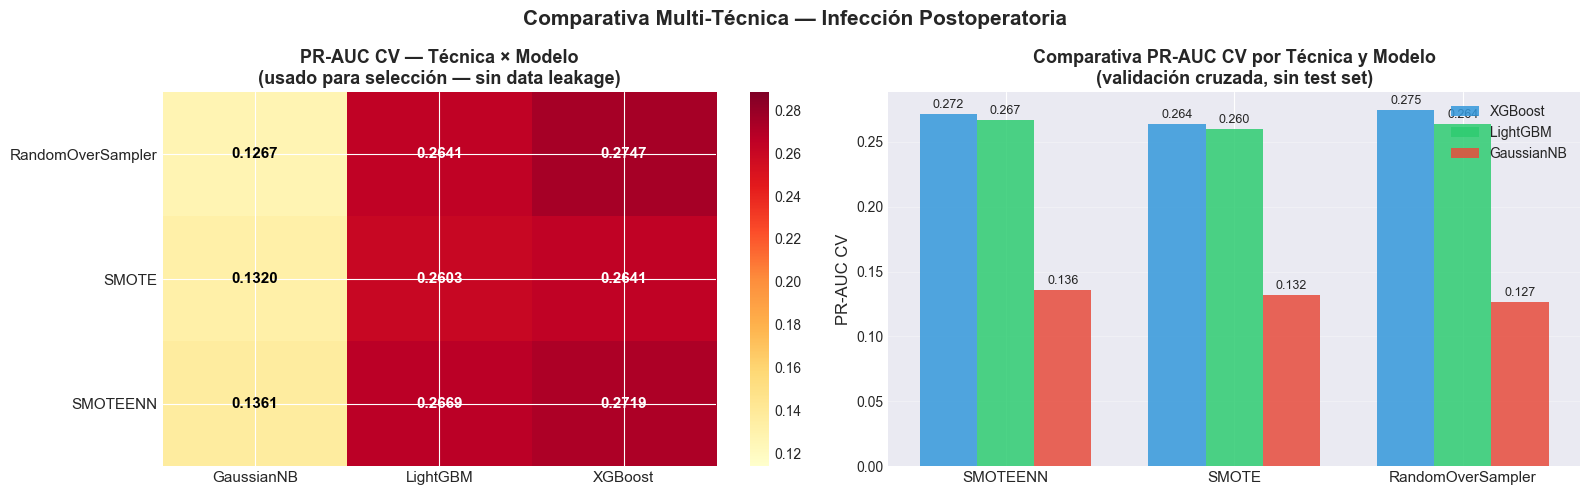


✓ Guardado: results/tabla_comparativa_tecnicas_infeccion.csv


In [70]:
df_comp = pd.DataFrame([{k: v for k, v in r.items() if k != 'best_pipeline'} for r in comp_results])
df_comp['best_params'] = df_comp['best_params'].astype(str)
df_sorted = df_comp.sort_values('cv_pr_auc', ascending=False).reset_index(drop=True)

print('\nTABLA COMPARATIVA: TÉCNICA × MODELO')
print('=' * 90)
print(df_sorted[['tecnica', 'modelo', 'cv_pr_auc', 'test_pr_auc', 'auc_roc', 'f1', 'recall']].to_string(index=False))

# ─── PR-AUC CV medio por técnica (sin usar el test set) ──────────────────────
# Se usa cv_pr_auc (score de validación cruzada sobre X_train) para la selección
# de BEST_TECNICA → evita data leakage: el test set no influye en esta decisión.
pr_por_tecnica = df_comp.groupby('tecnica')['cv_pr_auc'].mean().sort_values(ascending=False)
print(f'\nPR-AUC CV MEDIO POR TÉCNICA (promedio 3 modelos — sin usar test set):')
for tec, val in pr_por_tecnica.items():
    # Mostrar también test para referencia, pero NO se usa para selección
    test_val = df_comp.groupby('tecnica')['test_pr_auc'].mean()[tec]
    print(f'  {tec:<22}: CV={val:.4f}  (test ref={test_val:.4f})')

# ─── Heatmap (CV PR-AUC) ─────────────────────────────────────────────────────
pivot = df_comp.pivot(index='tecnica', columns='modelo', values='cv_pr_auc')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(pivot.values, cmap='YlOrRd', aspect='auto',
                    vmin=pivot.values.min() * 0.9, vmax=pivot.values.max() * 1.05)
axes[0].set_xticks(range(len(pivot.columns))); axes[0].set_xticklabels(pivot.columns, fontsize=11)
axes[0].set_yticks(range(len(pivot.index)));   axes[0].set_yticklabels(pivot.index, fontsize=11)
axes[0].set_title('PR-AUC CV — Técnica × Modelo\n(usado para selección — sin data leakage)',
                  fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[0])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        axes[0].text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=11, fontweight='bold',
                     color='white' if val > (pivot.values.max() * 0.85) else 'black')

tecnicas = list(TECNICAS_COMPARAR.keys())
x = np.arange(len(tecnicas)); width = 0.25
colors_mod = {'XGBoost': '#3498db', 'LightGBM': '#2ecc71', 'GaussianNB': '#e74c3c'}
for k, mod in enumerate(MODELOS_COMP):
    vals = [df_comp[(df_comp['tecnica'] == t) & (df_comp['modelo'] == mod)]['cv_pr_auc'].values[0]
            for t in tecnicas]
    bars = axes[1].bar(x + k * width, vals, width, label=mod, color=colors_mod[mod], alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x + width); axes[1].set_xticklabels(tecnicas, fontsize=11)
axes[1].set_ylabel('PR-AUC CV', fontsize=12)
axes[1].set_title('Comparativa PR-AUC CV por Técnica y Modelo\n(validación cruzada, sin test set)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('Comparativa Multi-Técnica — Infección Postoperatoria', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

df_comp.to_csv('results/tabla_comparativa_tecnicas_infeccion.csv', index=False)
print('\n✓ Guardado: results/tabla_comparativa_tecnicas_infeccion.csv')


In [71]:
# ─── Seleccionar la mejor técnica y redefinir SAMPLER_CLASS ──────────────────
# Ganadora: técnica con mejor PR-AUC CV medio (calculado sobre X_train solamente)
# El test set NO se usa en esta decisión → evita data leakage en selección de técnica.
best_row_comp = df_sorted.iloc[0]
BEST_TECNICA = pr_por_tecnica.index[0]

print('=' * 70)
print(f'✓ MEJOR TÉCNICA PARA INFECCIÓN: {BEST_TECNICA}')
print(f'  PR-AUC CV medio (3 modelos) = {pr_por_tecnica.iloc[0]:.4f}')
print(f'  Mejor combinación individual: {best_row_comp["tecnica"]} × {best_row_comp["modelo"]}')
print(f'  (CV PR-AUC={best_row_comp["cv_pr_auc"]:.4f} | test ref={best_row_comp["test_pr_auc"]:.4f})')
print('=' * 70)

# Redefinir SAMPLER_CLASS con la técnica ganadora
if BEST_TECNICA == 'SMOTEENN':
    def SAMPLER_CLASS(random_state=SEED, sampling_strategy=0.3):
        return SMOTEENN(random_state=random_state,
                       smote=SMOTE(random_state=random_state, sampling_strategy=sampling_strategy))
elif BEST_TECNICA == 'SMOTE':
    def SAMPLER_CLASS(random_state=SEED, sampling_strategy=0.3):
        return SMOTE(random_state=random_state, sampling_strategy=sampling_strategy)
elif BEST_TECNICA == 'RandomOverSampler':
    def SAMPLER_CLASS(random_state=SEED, sampling_strategy=0.3):
        return RandomOverSampler(random_state=random_state, sampling_strategy=sampling_strategy)

print(f'\n  SAMPLER_CLASS → {BEST_TECNICA}')
print(f'  Las fases 2, 3 y 4 usarán automáticamente esta técnica.')


✓ MEJOR TÉCNICA PARA INFECCIÓN: SMOTEENN
  PR-AUC CV medio (3 modelos) = 0.2250
  Mejor combinación individual: RandomOverSampler × XGBoost
  (CV PR-AUC=0.2747 | test ref=0.2250)

  SAMPLER_CLASS → SMOTEENN
  Las fases 2, 3 y 4 usarán automáticamente esta técnica.


---
## FASE 2: ENTRENAMIENTO BASELINE — 7 Modelos x mejor tecnica seleccionada

**Pipeline por modelo**:
```
ColumnTransformer: StandardScaler -> [edad, duracion_min, vital_fc, vital_ta_sist, vital_ta_dias]
                   passthrough    -> [ASA_Anestesia + 37 binarias]
-> SAMPLER_CLASS(sampling_strategy=0.3)  [solo sobre X_train, tecnica elegida en Fase 1b]
-> Entrenar modelo
-> Evaluar en X_test preprocesado
```

**Sin `class_weight='balanced'`**: el sampler ya balancea las clases; combinarlo duplicaria el efecto.


ENTRENAMIENTO BASELINE — INFECCION POSTOPERATORIA
Tras SMOTEENN: Clase 0=9648, Clase 1=3090

────────────────────────────────────────────────────────────────────────────────
MODELO: XGBoost
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9590 (IC: 0.9516-0.9665)
  Precision: 0.2899 (IC: 0.1828-0.3969)
  Recall:    0.2410 (IC: 0.1490-0.3330)
  F1-Score:  0.2632  |  AUC-ROC: 0.7927  |  PR-AUC: 0.2299
  Sensitivity: 0.2410 | Specificity: 0.9815


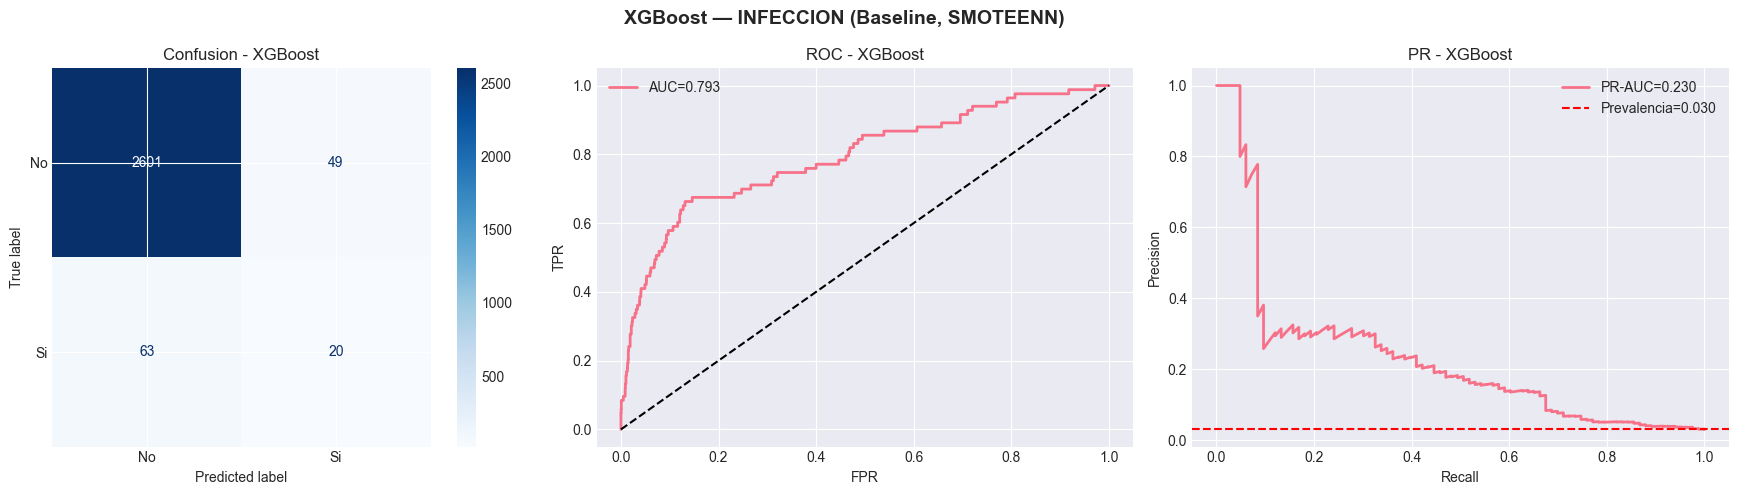


────────────────────────────────────────────────────────────────────────────────
MODELO: RandomForest
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9590 (IC: 0.9516-0.9665)
  Precision: 0.2958 (IC: 0.1896-0.4019)
  Recall:    0.2530 (IC: 0.1595-0.3465)
  F1-Score:  0.2727  |  AUC-ROC: 0.7959  |  PR-AUC: 0.2214
  Sensitivity: 0.2530 | Specificity: 0.9811


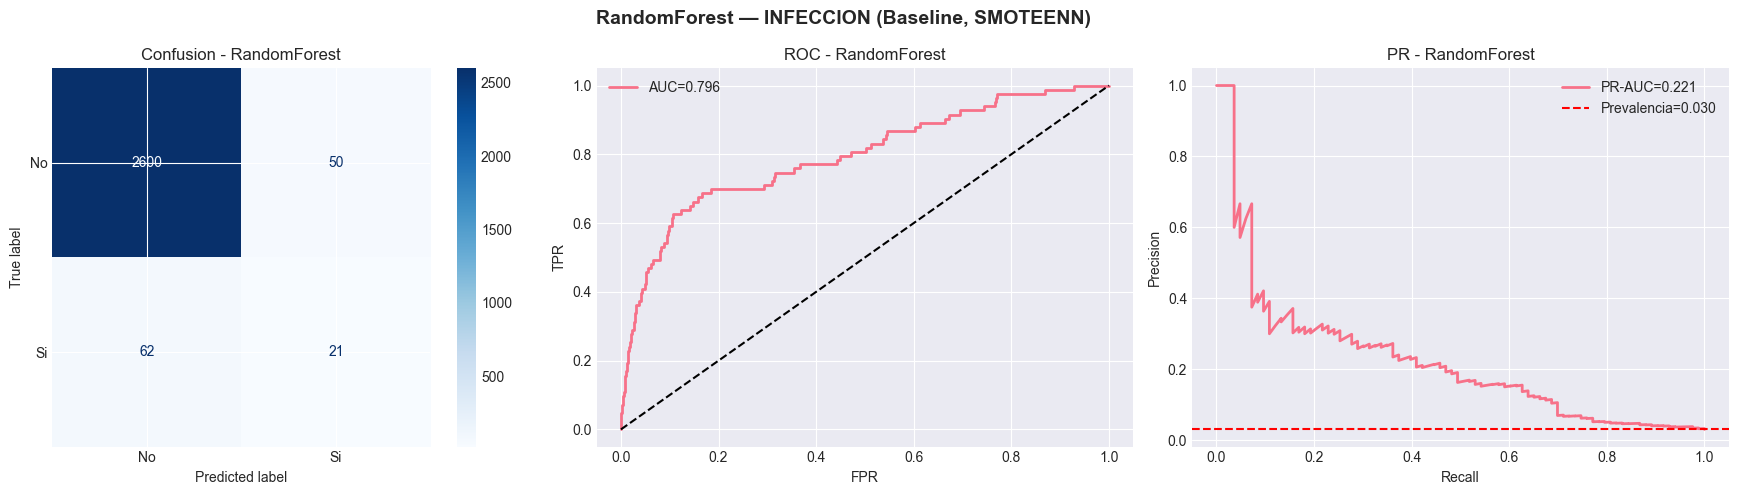


────────────────────────────────────────────────────────────────────────────────
MODELO: GradientBoosting
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9550 (IC: 0.9472-0.9628)
  Precision: 0.2727 (IC: 0.1797-0.3658)
  Recall:    0.2892 (IC: 0.1916-0.3867)
  F1-Score:  0.2807  |  AUC-ROC: 0.7817  |  PR-AUC: 0.2323
  Sensitivity: 0.2892 | Specificity: 0.9758


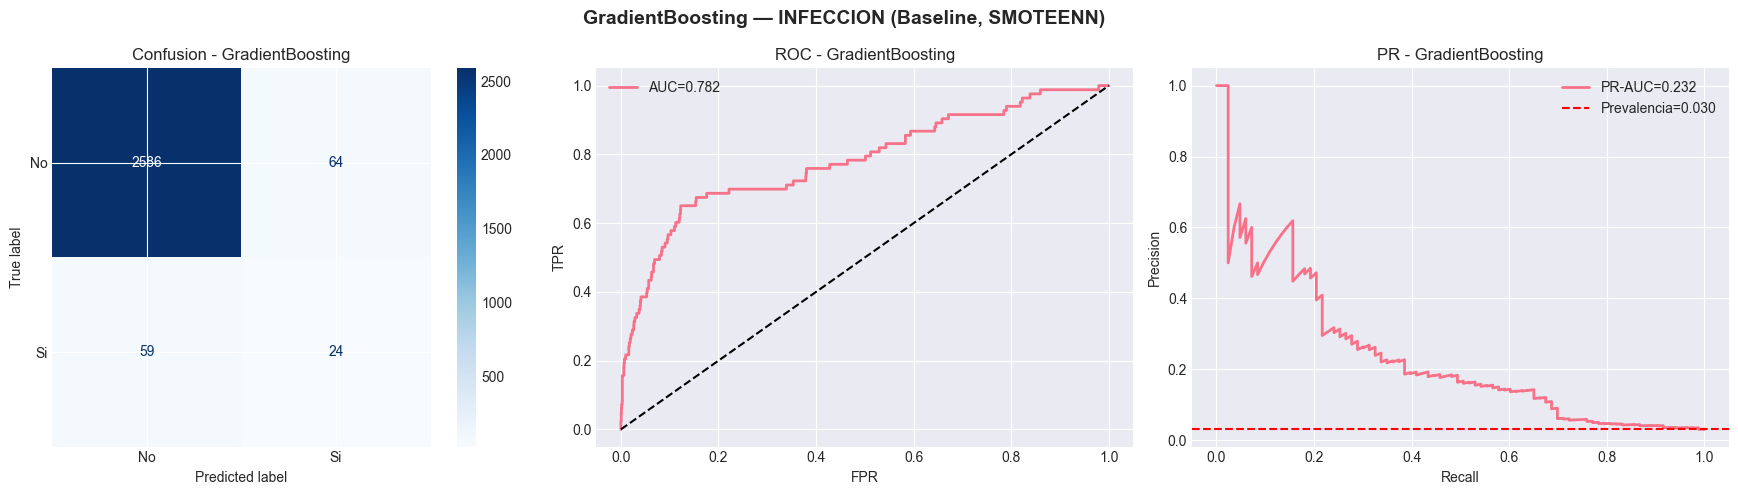


────────────────────────────────────────────────────────────────────────────────
MODELO: LogisticRegression
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9049 (IC: 0.8939-0.9159)
  Precision: 0.1635 (IC: 0.1188-0.2082)
  Recall:    0.5181 (IC: 0.4106-0.6256)
  F1-Score:  0.2486  |  AUC-ROC: 0.7611  |  PR-AUC: 0.1449
  Sensitivity: 0.5181 | Specificity: 0.9170


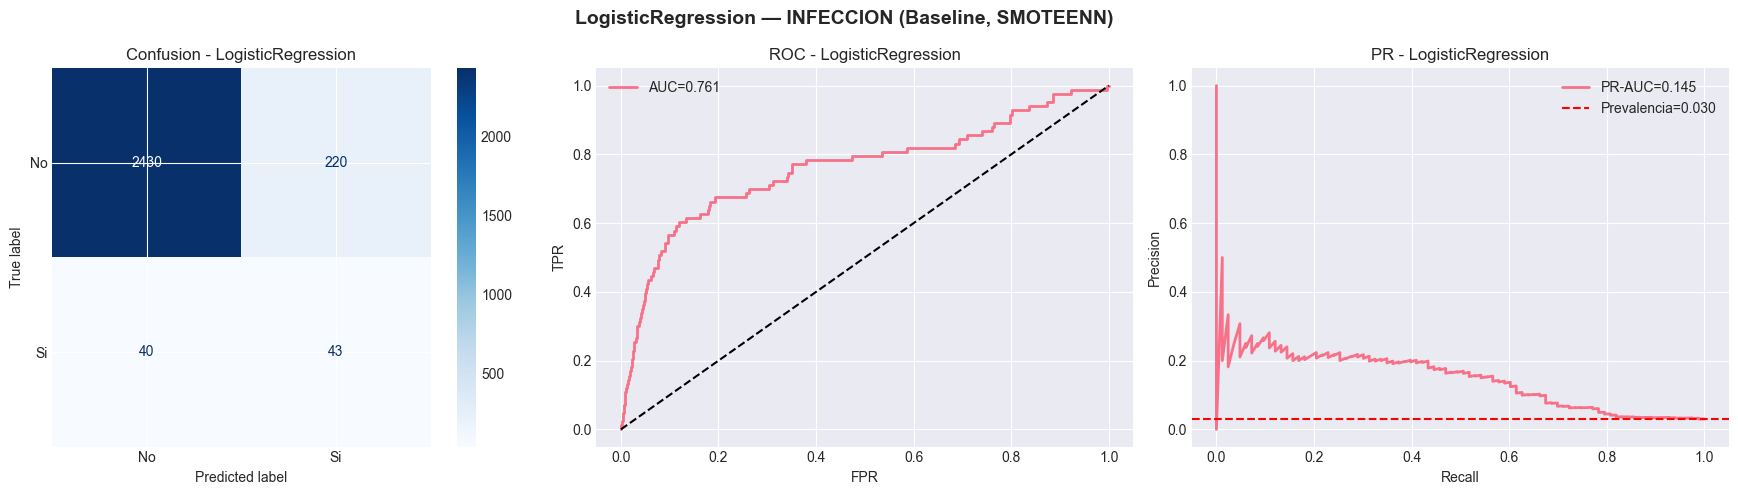


────────────────────────────────────────────────────────────────────────────────
MODELO: GaussianNB
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.7988 (IC: 0.7837-0.8138)
  Precision: 0.0939 (IC: 0.0701-0.1178)
  Recall:    0.6506 (IC: 0.5480-0.7532)
  F1-Score:  0.1641  |  AUC-ROC: 0.7464  |  PR-AUC: 0.2360
  Sensitivity: 0.6506 | Specificity: 0.8034


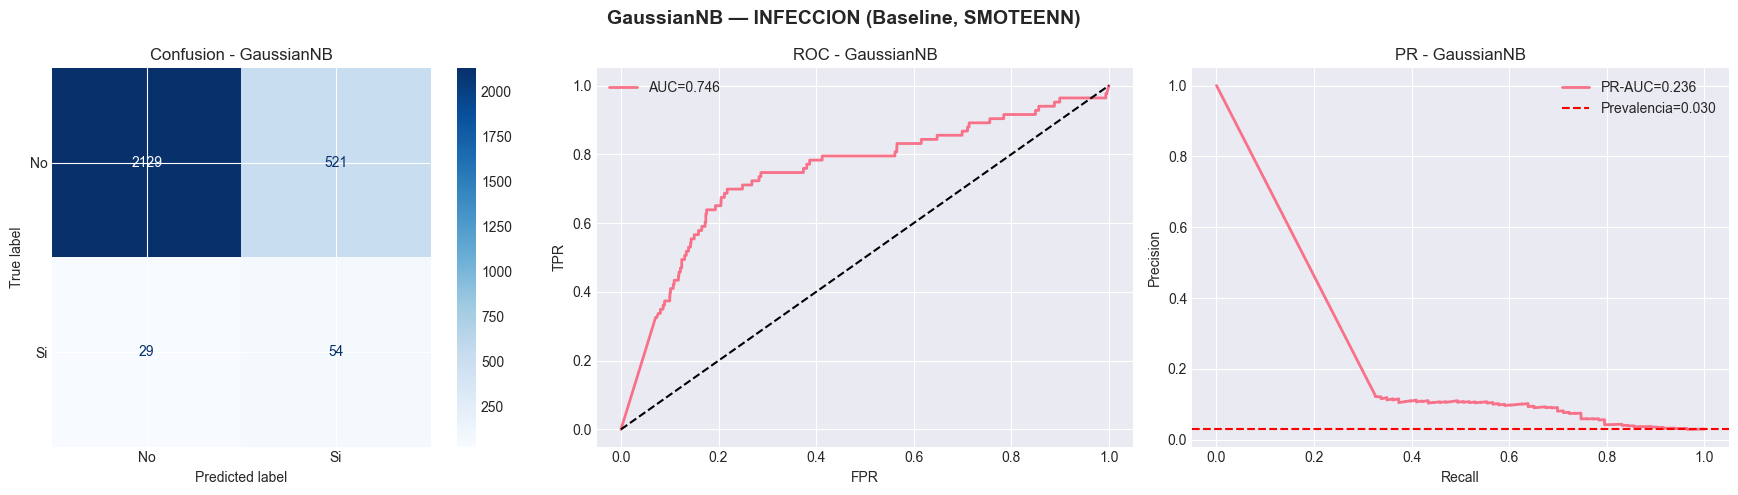


────────────────────────────────────────────────────────────────────────────────
MODELO: ExtraTrees
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9458 (IC: 0.9374-0.9543)
  Precision: 0.2269 (IC: 0.1516-0.3021)
  Recall:    0.3253 (IC: 0.2245-0.4261)
  F1-Score:  0.2673  |  AUC-ROC: 0.7956  |  PR-AUC: 0.2243
  Sensitivity: 0.3253 | Specificity: 0.9653


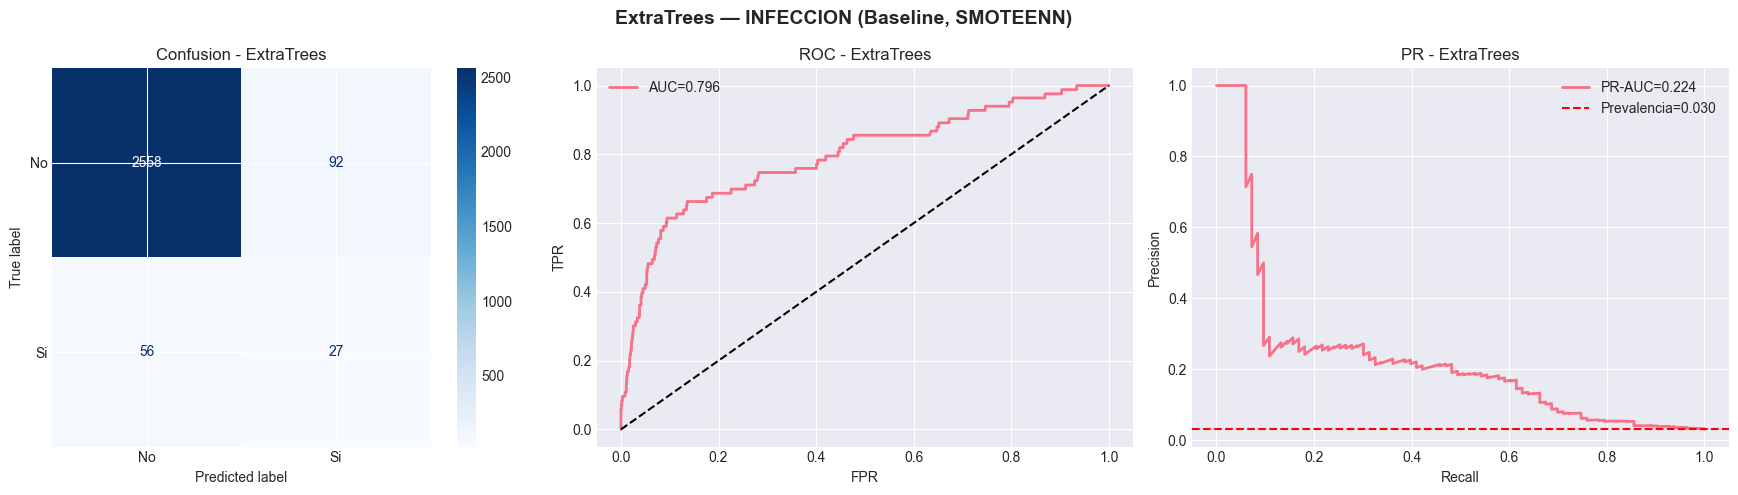


────────────────────────────────────────────────────────────────────────────────
MODELO: LightGBM
────────────────────────────────────────────────────────────────────────────────
  Accuracy:  0.9612 (IC: 0.9540-0.9685)
  Precision: 0.3175 (IC: 0.2025-0.4324)
  Recall:    0.2410 (IC: 0.1490-0.3330)
  F1-Score:  0.2740  |  AUC-ROC: 0.7934  |  PR-AUC: 0.2373
  Sensitivity: 0.2410 | Specificity: 0.9838


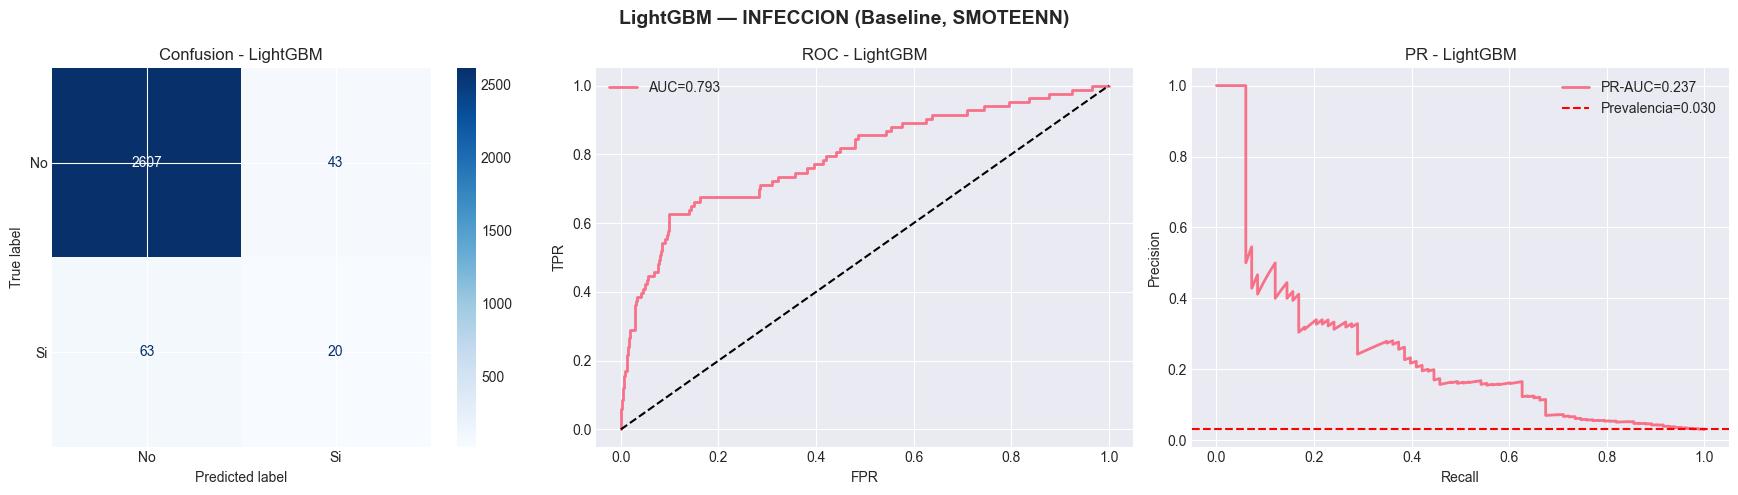

In [72]:
def calculate_metrics_with_ci(y_true, y_pred, y_pred_proba, ci=0.95):
    n_total=len(y_true); n_pred_pos=int(sum(y_pred)); n_actual_pos=int(y_true.sum())
    z_score = stats.norm.ppf((1+ci)/2)
    precision=precision_score(y_true,y_pred,zero_division=0)
    recall=recall_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    auc_val=roc_auc_score(y_true,y_pred_proba)
    accuracy=accuracy_score(y_true,y_pred)
    def ci_p(p,n):
        if n==0: return(0.,0.)
        se=np.sqrt(p*(1-p)/n)
        return max(0,p-z_score*se),min(1,p+z_score*se)
    return {'accuracy':accuracy,'accuracy_ci':ci_p(accuracy,n_total),
            'precision':precision,'precision_ci':ci_p(precision,n_pred_pos),
            'recall':recall,'recall_ci':ci_p(recall,n_actual_pos),
            'f1':f1,'f1_ci':None,'auc':auc_val,'auc_ci':None}

print('='*80); print('ENTRENAMIENTO BASELINE — INFECCION POSTOPERATORIA'); print('='*80)

preprocessor_bl, cols_out_bl = construir_preprocessor(X_train.columns.tolist())
X_train_proc = pd.DataFrame(preprocessor_bl.fit_transform(X_train), columns=cols_out_bl)
X_test_proc  = pd.DataFrame(preprocessor_bl.transform(X_test),      columns=cols_out_bl)

sampler_bl = SAMPLER_CLASS(random_state=SEED, sampling_strategy=0.3)
X_train_bal, y_train_bal = sampler_bl.fit_resample(X_train_proc, y_train)
print(f'Tras {BEST_TECNICA}: Clase 0={(y_train_bal==0).sum()}, Clase 1={(y_train_bal==1).sum()}')

resultados_baseline = {}
for nombre, (clase, params) in MODELOS_CONFIG.items():
    print(f"\n{'─'*80}\nMODELO: {nombre}\n{'─'*80}")
    try: modelo = clase(**params, random_state=SEED)
    except TypeError: modelo = clase(**params)
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test_proc)
    y_pred_proba = modelo.predict_proba(X_test_proc)[:,1]
    metrics = calculate_metrics_with_ci(y_test, y_pred, y_pred_proba)
    prec_v,rec_v,_ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc_score = auc(rec_v, prec_v)
    cm = confusion_matrix(y_test, y_pred); tn,fp,fn,tp = cm.ravel()
    sensitivity = tp/(tp+fn) if (tp+fn)>0 else 0
    specificity = tn/(tn+fp) if (tn+fp)>0 else 0
    print(f"  Accuracy:  {metrics['accuracy']:.4f} (IC: {metrics['accuracy_ci'][0]:.4f}-{metrics['accuracy_ci'][1]:.4f})")
    print(f"  Precision: {metrics['precision']:.4f} (IC: {metrics['precision_ci'][0]:.4f}-{metrics['precision_ci'][1]:.4f})")
    print(f"  Recall:    {metrics['recall']:.4f} (IC: {metrics['recall_ci'][0]:.4f}-{metrics['recall_ci'][1]:.4f})")
    print(f"  F1-Score:  {metrics['f1']:.4f}  |  AUC-ROC: {metrics['auc']:.4f}  |  PR-AUC: {pr_auc_score:.4f}")
    print(f'  Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}')
    resultados_baseline[nombre] = {'modelo':modelo,'metrics':metrics,'y_pred':y_pred,
        'y_pred_proba':y_pred_proba,'confusion_matrix':cm,'pr_auc':pr_auc_score,
        'sensitivity':sensitivity,'specificity':specificity,'preprocessor':preprocessor_bl,'cols_out':cols_out_bl}

    fig, axes = plt.subplots(1,3,figsize=(18,5))
    ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No','Si']).plot(ax=axes[0],cmap='Blues')
    axes[0].set_title(f'Confusion - {nombre}')
    fpr,tpr,_ = roc_curve(y_test,y_pred_proba)
    axes[1].plot(fpr,tpr,label=f'AUC={metrics["auc"]:.3f}',linewidth=2); axes[1].plot([0,1],[0,1],'k--')
    axes[1].set(xlabel='FPR',ylabel='TPR',title=f'ROC - {nombre}'); axes[1].legend()
    axes[2].plot(rec_v,prec_v,label=f'PR-AUC={pr_auc_score:.3f}',linewidth=2)
    axes[2].axhline(y_test.mean(),color='r',linestyle='--',label=f'Prevalencia={y_test.mean():.3f}')
    axes[2].set(xlabel='Recall',ylabel='Precision',title=f'PR - {nombre}'); axes[2].legend()
    plt.suptitle(f'{nombre} — INFECCION (Baseline, {BEST_TECNICA})',fontsize=14,fontweight='bold')
    plt.tight_layout(); plt.show()


In [73]:
print('\n'+'='*80); print('RESUMEN BASELINE — INFECCION'); print('='*80)
rows_bl = [{'Modelo':n,'PR-AUC':round(r['pr_auc'],4),'AUC-ROC':round(r['metrics']['auc'],4),
    'Recall':round(r['metrics']['recall'],4),'Precision':round(r['metrics']['precision'],4),
    'F1':round(r['metrics']['f1'],4),'Sensitivity':round(r['sensitivity'],4),'Specificity':round(r['specificity'],4)}
    for n,r in resultados_baseline.items()]
df_baseline = pd.DataFrame(rows_bl).sort_values('PR-AUC',ascending=False)
print(df_baseline.to_string(index=False))


RESUMEN BASELINE — INFECCION
            Modelo  PR-AUC  AUC-ROC  Recall  Precision     F1  Sensitivity  Specificity
          LightGBM  0.2373   0.7934  0.2410     0.3175 0.2740       0.2410       0.9838
        GaussianNB  0.2360   0.7464  0.6506     0.0939 0.1641       0.6506       0.8034
  GradientBoosting  0.2323   0.7817  0.2892     0.2727 0.2807       0.2892       0.9758
           XGBoost  0.2299   0.7927  0.2410     0.2899 0.2632       0.2410       0.9815
        ExtraTrees  0.2243   0.7956  0.3253     0.2269 0.2673       0.3253       0.9653
      RandomForest  0.2214   0.7959  0.2530     0.2958 0.2727       0.2530       0.9811
LogisticRegression  0.1449   0.7611  0.5181     0.1635 0.2486       0.5181       0.9170


---
## FASE 3: VALIDACION CRUZADA K-FOLD (5 folds)

K-Fold se ejecuta SOLO sobre el train set (80%). Se usa **StratifiedKFold** (no StratifiedGroupKFold)
porque el dataset ya esta deduplicado: 1 fila = 1 paciente.

Anti-leakage: preprocessor y sampler se reajustan en cada fold de forma independiente.


In [74]:
def validacion_cruzada_kfold(X_tr, y_tr, modelo_clase, modelo_params, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = {k:[] for k in ['accuracy','precision','recall','f1','auc','pr_auc','sensitivity','specificity']}
    for tr_idx, te_idx in skf.split(X_tr, y_tr):
        X_f_tr,X_f_te = X_tr.iloc[tr_idx],X_tr.iloc[te_idx]
        y_f_tr,y_f_te = y_tr.iloc[tr_idx],y_tr.iloc[te_idx]
        preprocessor,cols_out = construir_preprocessor(X_tr.columns.tolist())
        X_f_tr_p = pd.DataFrame(preprocessor.fit_transform(X_f_tr),columns=cols_out)
        X_f_te_p = pd.DataFrame(preprocessor.transform(X_f_te),columns=cols_out)
        sampler = SAMPLER_CLASS(random_state=random_state,sampling_strategy=0.3)
        X_f_bal,y_f_bal = sampler.fit_resample(X_f_tr_p,y_f_tr)
        try: modelo = modelo_clase(**modelo_params,random_state=random_state)
        except TypeError: modelo = modelo_clase(**modelo_params)
        modelo.fit(X_f_bal,y_f_bal)
        y_pred = modelo.predict(X_f_te_p)
        y_pred_proba = modelo.predict_proba(X_f_te_p)[:,1]
        fold_metrics['accuracy'].append(accuracy_score(y_f_te,y_pred))
        fold_metrics['precision'].append(precision_score(y_f_te,y_pred,zero_division=0))
        fold_metrics['recall'].append(recall_score(y_f_te,y_pred,zero_division=0))
        fold_metrics['f1'].append(f1_score(y_f_te,y_pred,zero_division=0))
        fold_metrics['auc'].append(roc_auc_score(y_f_te,y_pred_proba))
        prec_v,rec_v,_ = precision_recall_curve(y_f_te,y_pred_proba)
        fold_metrics['pr_auc'].append(auc(rec_v,prec_v))
        cm_f = confusion_matrix(y_f_te,y_pred); tn_f,fp_f,fn_f,tp_f = cm_f.ravel()
        fold_metrics['sensitivity'].append(tp_f/(tp_f+fn_f) if (tp_f+fn_f)>0 else 0)
        fold_metrics['specificity'].append(tn_f/(tn_f+fp_f) if (tn_f+fp_f)>0 else 0)
    nombres_m = {'accuracy':'Accuracy','precision':'Precision','recall':'Recall','f1':'F1-Score',
                 'auc':'AUC-ROC','pr_auc':'PR-AUC','sensitivity':'Sensitivity','specificity':'Specificity'}
    rows = [{'Metrica':nombres_m[k],'Media':round(np.mean(v),4),'Desv.Est':round(np.std(v),4),
             'Min':round(np.min(v),4),'Max':round(np.max(v),4)} for k,v in fold_metrics.items()]
    return {'fold_metrics':fold_metrics,'resumen':pd.DataFrame(rows)}

print('Funcion validacion_cruzada_kfold definida.')

Funcion validacion_cruzada_kfold definida.


In [75]:
print('='*100); print(f'K-FOLD: INFECCION (5 folds x 7 modelos) — Tecnica: {BEST_TECNICA}'); print('='*100)

_ck_kf = f'kfold_infeccion_{BEST_TECNICA}.pkl'
kfold_results = load_checkpoint(_ck_kf)
if kfold_results is None:
    kfold_results = {}
    for nombre,(clase,params) in MODELOS_CONFIG.items():
        print(f"\n{'─'*80}\nK-Fold -> {nombre}\n{'─'*80}")
        _t0 = time.time()
        kfold_results[nombre] = validacion_cruzada_kfold(X_train, y_train, clase, params)
        kfold_results[nombre]['tiempo_seg'] = round(time.time()-_t0,1)
        res = kfold_results[nombre]['resumen']
        pr = res[res['Metrica']=='PR-AUC'].iloc[0]
        au = res[res['Metrica']=='AUC-ROC'].iloc[0]
        print(f"  PR-AUC:  {pr['Media']:.4f} +/- {pr['Desv.Est']:.4f}")
        print(f"  AUC-ROC: {au['Media']:.4f} +/- {au['Desv.Est']:.4f}")
    save_checkpoint(kfold_results, _ck_kf)
    print(f'\n✓ K-Fold INFECCION completado ({BEST_TECNICA})')
else:
    print('✓ K-Fold cargado desde checkpoint')


K-FOLD: INFECCION (5 folds x 7 modelos) — Tecnica: SMOTEENN

────────────────────────────────────────────────────────────────────────────────
K-Fold -> XGBoost
────────────────────────────────────────────────────────────────────────────────
  PR-AUC:  0.2489 +/- 0.0594
  AUC-ROC: 0.8537 +/- 0.0197

────────────────────────────────────────────────────────────────────────────────
K-Fold -> RandomForest
────────────────────────────────────────────────────────────────────────────────
  PR-AUC:  0.2409 +/- 0.0471
  AUC-ROC: 0.8555 +/- 0.0277

────────────────────────────────────────────────────────────────────────────────
K-Fold -> GradientBoosting
────────────────────────────────────────────────────────────────────────────────
  PR-AUC:  0.2416 +/- 0.0638
  AUC-ROC: 0.8570 +/- 0.0205

────────────────────────────────────────────────────────────────────────────────
K-Fold -> LogisticRegression
────────────────────────────────────────────────────────────────────────────────
  PR-AUC:  0.2335

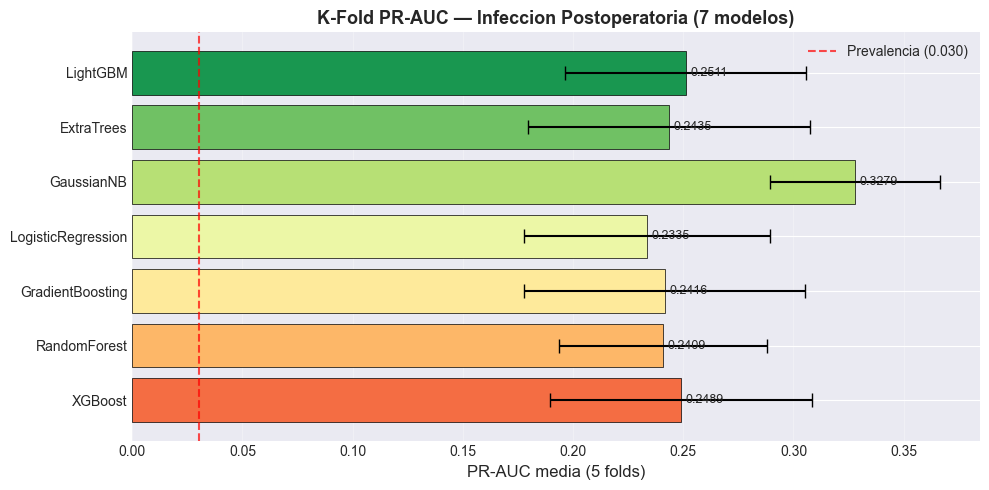


Resumen K-Fold:
  XGBoost               : PR-AUC=0.2489+/-0.0594 | AUC-ROC=0.8537+/-0.0197
  RandomForest          : PR-AUC=0.2409+/-0.0471 | AUC-ROC=0.8555+/-0.0277
  GradientBoosting      : PR-AUC=0.2416+/-0.0638 | AUC-ROC=0.8570+/-0.0205
  LogisticRegression    : PR-AUC=0.2335+/-0.0558 | AUC-ROC=0.8425+/-0.0356
  GaussianNB            : PR-AUC=0.3279+/-0.0384 | AUC-ROC=0.8292+/-0.0361
  ExtraTrees            : PR-AUC=0.2435+/-0.0638 | AUC-ROC=0.8497+/-0.0346
  LightGBM              : PR-AUC=0.2511+/-0.0548 | AUC-ROC=0.8576+/-0.0153


In [76]:
nombres_kf = list(kfold_results.keys())
pr_medias = [kfold_results[n]['resumen'][kfold_results[n]['resumen']['Metrica']=='PR-AUC']['Media'].iloc[0] for n in nombres_kf]
pr_stds   = [kfold_results[n]['resumen'][kfold_results[n]['resumen']['Metrica']=='PR-AUC']['Desv.Est'].iloc[0] for n in nombres_kf]
fig,ax = plt.subplots(figsize=(10,5))
colors_b = plt.cm.RdYlGn(np.linspace(0.2,0.9,len(nombres_kf)))
bars = ax.barh(nombres_kf,pr_medias,xerr=pr_stds,capsize=5,color=colors_b,edgecolor='black',linewidth=0.5)
ax.set_xlabel('PR-AUC media (5 folds)',fontsize=12)
ax.set_title('K-Fold PR-AUC — Infeccion Postoperatoria (7 modelos)',fontsize=13,fontweight='bold')
for bar,val in zip(bars,pr_medias): ax.text(val+0.002,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=9)
ax.axvline(y_test.mean(),color='red',linestyle='--',alpha=0.7,label=f'Prevalencia ({y_test.mean():.3f})')
ax.legend(); ax.grid(axis='x',alpha=0.3); plt.tight_layout(); plt.show()

print('\nResumen K-Fold:')
for nombre in nombres_kf:
    res = kfold_results[nombre]['resumen']
    pr=res[res['Metrica']=='PR-AUC'].iloc[0]; au=res[res['Metrica']=='AUC-ROC'].iloc[0]
    print(f"  {nombre:<22}: PR-AUC={pr['Media']:.4f}+/-{pr['Desv.Est']:.4f} | AUC-ROC={au['Media']:.4f}+/-{au['Desv.Est']:.4f}")

---
## FASE 4: GRIDSEARCH — Optimizacion de hiperparametros (7 modelos)

GridSearchCV con `scoring='average_precision'` (PR-AUC). Pipeline completo dentro de cada fold: ColumnTransformer -> SAMPLER_CLASS -> Modelo. **Sin data leakage**: preprocessor y sampler se reajustan en cada fold.


In [77]:
PARAM_GRIDS = {
    'XGBoost':           {'model__max_depth':[3,5],'model__learning_rate':[0.05,0.1,0.2],'model__n_estimators':[100,200],'model__subsample':[0.8,1.0],'model__colsample_bytree':[0.8,1.0]},
    'RandomForest':      {'model__n_estimators':[100,200],'model__max_depth':[5,10,None],'model__min_samples_leaf':[1,5,10],'model__max_features':['sqrt','log2']},
    'GradientBoosting':  {'model__n_estimators':[100,200],'model__learning_rate':[0.05,0.1,0.2],'model__max_depth':[3,5],'model__subsample':[0.8,1.0]},
    'LogisticRegression':{'model__C':[0.01,0.1,1.0,10.0],'model__penalty':['l1','l2']},
    'GaussianNB':        {'model__var_smoothing':[1e-9,1e-8,1e-7,1e-6,1e-5]},
    'ExtraTrees':        {'model__n_estimators':[100,200],'model__max_depth':[5,10,None],'model__min_samples_leaf':[1,5,10],'model__max_features':['sqrt','log2']},
    'LightGBM':          {'model__n_estimators':[100,200],'model__max_depth':[3,5,-1],'model__learning_rate':[0.05,0.1,0.2],'model__num_leaves':[15,31,63]},
}

def optimizar_gridsearch(X_tr, y_tr, X_te, y_te, modelo_tipo, cv=5):
    print(f"\n{'─'*100}\nGridSearch -> {modelo_tipo}\n{'─'*100}")
    if modelo_tipo=='XGBoost': modelo=xgb.XGBClassifier(random_state=SEED,eval_metric='logloss',n_jobs=1)
    elif modelo_tipo=='RandomForest': modelo=RandomForestClassifier(random_state=SEED,n_jobs=1)
    elif modelo_tipo=='GradientBoosting': modelo=GradientBoostingClassifier(random_state=SEED)
    elif modelo_tipo=='LogisticRegression': modelo=LogisticRegression(random_state=SEED,max_iter=2000,solver='liblinear')
    elif modelo_tipo=='GaussianNB': modelo=GaussianNB()
    elif modelo_tipo=='ExtraTrees': modelo=ExtraTreesClassifier(random_state=SEED,n_jobs=1)
    elif modelo_tipo=='LightGBM': modelo=lgb.LGBMClassifier(random_state=SEED,verbose=-1,n_jobs=1)
    else: raise ValueError(f'No soportado: {modelo_tipo}')

    preprocessor,_ = construir_preprocessor(X_tr.columns.tolist())
    pipeline = ImbPipeline([('preprocessor',preprocessor),
                            ('sampler',SAMPLER_CLASS(random_state=SEED,sampling_strategy=0.3)),
                            ('model',modelo)])
    param_grid = PARAM_GRIDS[modelo_tipo]
    total_combos = 1
    for v in param_grid.values(): total_combos *= len(v)
    print(f'  Combinaciones: {total_combos} x {cv} folds = {total_combos*cv} entrenamientos')

    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv_strategy, scoring='average_precision',
                               n_jobs=-1, verbose=0, return_train_score=True)
    grid_search.fit(X_tr, y_tr)

    cv_res = grid_search.cv_results_
    print(f"\n  {'Rank':>5}  {'CV PR-AUC':>10}  Parametros"); print(f"  {'─'*90}")
    for _i in cv_res['rank_test_score'].argsort():
        _params = {k.replace('model__',''):v for k,v in cv_res['params'][_i].items()}
        _pstr = ', '.join(f'{k}={v}' for k,v in _params.items())
        _mark = '  ◄ MEJOR' if cv_res['rank_test_score'][_i]==1 else ''
        print(f"  #{cv_res['rank_test_score'][_i]:>4}  {cv_res['mean_test_score'][_i]:>10.4f}  {_pstr}{_mark}")
    print(f"  {'─'*90}")

    best_pipeline = grid_search.best_estimator_
    y_pred = best_pipeline.predict(X_te); y_pred_proba = best_pipeline.predict_proba(X_te)[:,1]
    acc=accuracy_score(y_te,y_pred); prec=precision_score(y_te,y_pred,zero_division=0)
    rec=recall_score(y_te,y_pred,zero_division=0); f1=f1_score(y_te,y_pred,zero_division=0)
    auc_roc=roc_auc_score(y_te,y_pred_proba)
    prec_v,rec_v,_ = precision_recall_curve(y_te,y_pred_proba); pr_auc_score=auc(rec_v,prec_v)
    cm=confusion_matrix(y_te,y_pred); tn,fp,fn,tp=cm.ravel()
    sensitivity=tp/(tp+fn) if (tp+fn)>0 else 0; specificity=tn/(tn+fp) if (tn+fp)>0 else 0
    best_params_clean = {k.replace('model__',''):v for k,v in grid_search.best_params_.items()}
    print(f'  Mejores params: {best_params_clean}')
    print(f'  CV Score (PR-AUC): {grid_search.best_score_:.4f}')
    print(f'  Test -> PR-AUC: {pr_auc_score:.4f} | AUC-ROC: {auc_roc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}')
    best_preprocessor = best_pipeline.named_steps['preprocessor']
    _,cols_out_gs = construir_preprocessor(X_tr.columns.tolist())
    X_test_proc = pd.DataFrame(best_preprocessor.transform(X_te),columns=cols_out_gs)
    return {'best_model':best_pipeline.named_steps['model'],'best_pipeline':best_pipeline,
            'best_params':best_params_clean,'cv_score':grid_search.best_score_,
            'preprocessor':best_preprocessor,'cols_out':cols_out_gs,
            'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,'auc_roc':auc_roc,'pr_auc':pr_auc_score,
            'sensitivity':sensitivity,'specificity':specificity,'confusion_matrix':cm,
            'y_pred':y_pred,'y_pred_proba':y_pred_proba,'tp':tp,'fp':fp,'tn':tn,'fn':fn,'y_test':y_te,
            'X_test_scaled':X_test_proc}

print('Funcion optimizar_gridsearch definida.')

Funcion optimizar_gridsearch definida.


In [78]:
print('='*100); print(f'GRIDSEARCH CV: INFECCION POSTOPERATORIA (7 modelos) — Tecnica: {BEST_TECNICA}'); print('='*100)

_ck_gs = f'gs_infeccion_{BEST_TECNICA}.pkl'
gs_results = load_checkpoint(_ck_gs)
if gs_results is None:
    gs_results = {}
    for nombre in MODELOS_CONFIG:
        _t0 = time.time()
        gs_results[nombre] = optimizar_gridsearch(X_train, y_train, X_test, y_test, modelo_tipo=nombre)
        gs_results[nombre]['tiempo_seg'] = round(time.time()-_t0,1)
    save_checkpoint(gs_results, _ck_gs)
    print(f'\n✓ GridSearch INFECCION completado ({BEST_TECNICA})')
else:
    print('✓ GridSearch cargado desde checkpoint')


GRIDSEARCH CV: INFECCION POSTOPERATORIA (7 modelos) — Tecnica: SMOTEENN

────────────────────────────────────────────────────────────────────────────────────────────────────
GridSearch -> XGBoost
────────────────────────────────────────────────────────────────────────────────────────────────────
  Combinaciones: 48 x 5 folds = 240 entrenamientos

   Rank   CV PR-AUC  Parametros
  ──────────────────────────────────────────────────────────────────────────────────────────
  #   1      0.2719  colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8  ◄ MEJOR
  #   2      0.2712  colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8
  #   3      0.2686  colsample_bytree=1.0, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=1.0
  #   4      0.2668  colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8
  #   5      0.2661  colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimato

---
## FASE 5: TABLA COMPARATIVA + SELECCION DE MODELOS + UMBRAL OPTIMO + LEARNING CURVES

In [79]:
print('='*140); print('TABLA COMPARATIVA GLOBAL — BASELINE vs K-FOLD vs GRIDSEARCH (INFECCION)'); print('='*140)
all_results = []
for nombre,res in resultados_baseline.items():
    m=res['metrics']
    all_results.append({'Fase':'Baseline','Modelo':nombre,'Accuracy':round(m['accuracy'],4),
        'Precision':round(m['precision'],4),'Recall':round(m['recall'],4),'F1':round(m['f1'],4),
        'AUC-ROC':round(m['auc'],4),'PR-AUC':round(res['pr_auc'],4),
        'Sensitivity':round(res['sensitivity'],4),'Specificity':round(res['specificity'],4),'Info':'Params fijos'})
for nombre,res in kfold_results.items():
    resumen=res['resumen']
    def get_val(mn): row=resumen[resumen['Metrica']==mn].iloc[0]; return round(row['Media'],4),round(row['Desv.Est'],4)
    pr_m,pr_s=get_val('PR-AUC'); auc_m,_=get_val('AUC-ROC'); rec_m,_=get_val('Recall')
    f1_m,_=get_val('F1-Score'); prec_m,_=get_val('Precision'); acc_m,_=get_val('Accuracy')
    sen_m,_=get_val('Sensitivity'); spe_m,_=get_val('Specificity')
    all_results.append({'Fase':'K-Fold (5)','Modelo':nombre,'Accuracy':acc_m,'Precision':prec_m,
        'Recall':rec_m,'F1':f1_m,'AUC-ROC':auc_m,'PR-AUC':pr_m,'Sensitivity':sen_m,'Specificity':spe_m,
        'Info':f'+/-{pr_s:.4f} (PR-AUC std)'})
for nombre,res in gs_results.items():
    all_results.append({'Fase':'GridSearch','Modelo':nombre,'Accuracy':round(res['accuracy'],4),
        'Precision':round(res['precision'],4),'Recall':round(res['recall'],4),'F1':round(res['f1'],4),
        'AUC-ROC':round(res['auc_roc'],4),'PR-AUC':round(res['pr_auc'],4),
        'Sensitivity':round(res['sensitivity'],4),'Specificity':round(res['specificity'],4),'Info':str(res['best_params'])})
df_comparativa = pd.DataFrame(all_results)
for fase in ['Baseline','K-Fold (5)','GridSearch']:
    df_f = df_comparativa[df_comparativa['Fase']==fase].sort_values('PR-AUC',ascending=False)
    print(f"\n{'─'*120}\n  {fase}\n{'─'*120}")
    print(df_f[['Modelo','PR-AUC','AUC-ROC','Recall','Precision','F1','Sensitivity','Specificity']].to_string(index=False))
df_comparativa.to_csv('results/tabla_comparativa_infeccion.csv',index=False)
print(f'\n✓ Tabla guardada: results/tabla_comparativa_infeccion.csv')

TABLA COMPARATIVA GLOBAL — BASELINE vs K-FOLD vs GRIDSEARCH (INFECCION)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Baseline
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
            Modelo  PR-AUC  AUC-ROC  Recall  Precision     F1  Sensitivity  Specificity
          LightGBM  0.2373   0.7934  0.2410     0.3175 0.2740       0.2410       0.9838
        GaussianNB  0.2360   0.7464  0.6506     0.0939 0.1641       0.6506       0.8034
  GradientBoosting  0.2323   0.7817  0.2892     0.2727 0.2807       0.2892       0.9758
           XGBoost  0.2299   0.7927  0.2410     0.2899 0.2632       0.2410       0.9815
        ExtraTrees  0.2243   0.7956  0.3253     0.2269 0.2673       0.3253       0.9653
      RandomForest  0.2214   0.7959  0.2530     0.2958 0.2727       0.2530       0.9811
LogisticRegression  0.1449   0.7611  0.5181     0.1635 0.2

In [80]:
print('\n'+'='*120); print('SELECCION FINAL: TOP 2 MODELOS (ALGORITMOS DIFERENTES)'); print('='*120)
df_gs = df_comparativa[df_comparativa['Fase']=='GridSearch']
df_calidad = df_gs[(df_gs['AUC-ROC']>=0.6)&(df_gs['F1']>=0.05)]
if len(df_calidad)>=2:
    df_sel=df_calidad.sort_values('PR-AUC',ascending=False)
    print(f'  Filtro de calidad: {len(df_calidad)} candidatos validos (AUC-ROC>=0.6, F1>=0.05)')
else:
    df_sel=df_gs.sort_values('PR-AUC',ascending=False)
    print(f'  Filtro de calidad: solo {len(df_calidad)} pasaron, usando lista completa')
best1=df_sel.iloc[0]; best2=None
for _,row in df_sel.iloc[1:].iterrows():
    if row['Modelo']!=best1['Modelo']: best2=row; break
mejor_final = {
    'top1':{'modelo':best1['Modelo'],'fase':'GridSearch','pr_auc':best1['PR-AUC'],'auc_roc':best1['AUC-ROC'],
            'recall':best1['Recall'],'f1':best1['F1'],'precision':best1['Precision'],'specificity':best1['Specificity'],'info':best1['Info']},
    'top2':{'modelo':best2['Modelo'],'fase':'GridSearch','pr_auc':best2['PR-AUC'],'auc_roc':best2['AUC-ROC'],
            'recall':best2['Recall'],'f1':best2['F1'],'precision':best2['Precision'],'specificity':best2['Specificity'],'info':best2['Info']} if best2 is not None else None
}
for rank_label,rank_key in [('TOP 1','top1'),('TOP 2','top2')]:
    info=mejor_final[rank_key]
    if info is None: continue
    print(f"\n{'─'*100}\n  {rank_label}: {info['modelo']} (GridSearch)\n{'─'*100}")
    print(f"  GridSearch -> PR-AUC: {info['pr_auc']:.4f} | AUC-ROC: {info['auc_roc']:.4f} | F1: {info['f1']:.4f} | Recall: {info['recall']:.4f}")
    print(f"  Parametros: {info['info']}")


SELECCION FINAL: TOP 2 MODELOS (ALGORITMOS DIFERENTES)
  Filtro de calidad: 7 candidatos validos (AUC-ROC>=0.6, F1>=0.05)

────────────────────────────────────────────────────────────────────────────────────────────────────
  TOP 1: LightGBM (GridSearch)
────────────────────────────────────────────────────────────────────────────────────────────────────
  GridSearch -> PR-AUC: 0.2472 | AUC-ROC: 0.7881 | F1: 0.3165 | Recall: 0.3012
  Parametros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 63}

────────────────────────────────────────────────────────────────────────────────────────────────────
  TOP 2: GradientBoosting (GridSearch)
────────────────────────────────────────────────────────────────────────────────────────────────────
  GridSearch -> PR-AUC: 0.2446 | AUC-ROC: 0.7851 | F1: 0.3121 | Recall: 0.3253
  Parametros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [81]:
def bootstrap_ci_metricas(y_true, y_proba, n_boot=1000, ci=0.95, seed=SEED):
    rng=np.random.RandomState(seed); pr_aucs,auc_rocs=[],[]
    for _ in range(n_boot):
        idx=rng.choice(len(y_true),size=len(y_true),replace=True)
        yt=np.array(y_true)[idx]; yp=np.array(y_proba)[idx]
        if len(np.unique(yt))<2: continue
        prec_v,rec_v,_=precision_recall_curve(yt,yp)
        pr_aucs.append(auc(rec_v,prec_v)); auc_rocs.append(roc_auc_score(yt,yp))
    alpha=(1-ci)/2
    return {'pr_auc':np.mean(pr_aucs),'pr_auc_lo':np.percentile(pr_aucs,alpha*100),'pr_auc_hi':np.percentile(pr_aucs,(1-alpha)*100),
            'auc_roc':np.mean(auc_rocs),'auc_roc_lo':np.percentile(auc_rocs,alpha*100),'auc_roc_hi':np.percentile(auc_rocs,(1-alpha)*100)}

print('='*120); print('IC 95% (Bootstrap, n=1000)'); print('='*120)
print(f"  {'Rank':<6} {'Modelo':<22} {'PR-AUC':>8}  {'IC 95% PR-AUC':>22}  {'AUC-ROC':>8}  {'IC 95% AUC-ROC':>22}")
print(f"  {'─'*95}")
bootstrap_results = {}
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    nombre=info['modelo']; y_proba=gs_results[nombre]['y_pred_proba']
    ci_res=bootstrap_ci_metricas(y_test.values,y_proba)
    rank_l='Top 1' if rank=='top1' else 'Top 2'
    bootstrap_results[rank]=ci_res
    print(f"  {rank_l:<6} {nombre:<22}  {ci_res['pr_auc']:>8.4f}  [{ci_res['pr_auc_lo']:.4f} - {ci_res['pr_auc_hi']:.4f}]  {ci_res['auc_roc']:>8.4f}  [{ci_res['auc_roc_lo']:.4f} - {ci_res['auc_roc_hi']:.4f}]")
print(f'\n✓ Bootstrap CI calculados (test: {len(y_test):,} muestras, {y_test.sum()} positivos)')

IC 95% (Bootstrap, n=1000)
  Rank   Modelo                   PR-AUC           IC 95% PR-AUC   AUC-ROC          IC 95% AUC-ROC
  ───────────────────────────────────────────────────────────────────────────────────────────────
  Top 1  LightGBM                  0.2496  [0.1583 - 0.3526]    0.7875  [0.7252 - 0.8472]
  Top 2  GradientBoosting          0.2475  [0.1535 - 0.3529]    0.7848  [0.7218 - 0.8450]

✓ Bootstrap CI calculados (test: 2,733 muestras, 83 positivos)


### Fase 5b: Umbral optimo (sin data leakage)

SMOTEENN entrena con ~30% de positivos pero prevalencia real = 3.02%. El umbral 0.50 esta desajustado.

Se optimiza el umbral usando predicciones **out-of-fold** del train set — nunca toca el test set.

In [82]:
def calcular_threshold_optimo_en_cv(pipeline, X_tr, y_tr, modelo_nombre):
    from sklearn.model_selection import cross_val_predict
    print(f'\n  Calculando umbral optimo (en CV) para {modelo_nombre}...')
    skf_thr = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    y_pred_proba_cv = cross_val_predict(pipeline,X_tr,y_tr,cv=skf_thr,method='predict_proba',n_jobs=1)[:,1]
    prec_vals,rec_vals,thr_pr = precision_recall_curve(y_tr,y_pred_proba_cv)
    fpr,tpr,thr_roc = roc_curve(y_tr,y_pred_proba_cv)
    f1_arr = 2*prec_vals[:-1]*rec_vals[:-1]/(prec_vals[:-1]+rec_vals[:-1]+1e-9)
    thr_f1 = float(thr_pr[np.argmax(f1_arr)])
    mask_r = rec_vals[:-1]>=0.80
    thr_r80 = float(thr_pr[mask_r][np.argmax(prec_vals[:-1][mask_r])]) if mask_r.any() else thr_f1
    thr_youden = float(thr_roc[np.argmax(tpr-fpr)])
    thresholds = {'Default (0.50)':0.50,'Maximo F1':thr_f1,'Recall >= 0.80':thr_r80,'Youden J':thr_youden}
    print('  ✓ Umbrales calculados:')
    for nombre,umbral in thresholds.items(): print(f'    - {nombre:<20s}: {umbral:.4f}')
    return thresholds

def evaluar_threshold_en_test(y_te, y_pred_proba_test, thresholds_optimos, modelo_nombre):
    print(f"\n{'='*90}\n  EVALUACION CON UMBRAL OPTIMO — INFECCION: {modelo_nombre}\n{'='*90}")
    print(f"  {'Estrategia':<20} {'Umbral':>8} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Specificity':>12}")
    print(f"  {'-'*74}")
    for estrategia,umbral in thresholds_optimos.items():
        y_pred_thr=(y_pred_proba_test>=umbral).astype(int)
        prec=precision_score(y_te,y_pred_thr,zero_division=0)
        rec=recall_score(y_te,y_pred_thr,zero_division=0)
        f1=f1_score(y_te,y_pred_thr,zero_division=0)
        cm_t=confusion_matrix(y_te,y_pred_thr); tn_t,fp_t,fn_t,tp_t=cm_t.ravel()
        spec=tn_t/(tn_t+fp_t) if (tn_t+fp_t)>0 else 0
        print(f'  {estrategia:<20} {umbral:>8.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {spec:>12.4f}')

for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    nombre=info['modelo']
    thresholds=calcular_threshold_optimo_en_cv(gs_results[nombre]['best_pipeline'],X_train,y_train,nombre)
    evaluar_threshold_en_test(y_test,gs_results[nombre]['y_pred_proba'],thresholds,nombre)


  Calculando umbral optimo (en CV) para LightGBM...
  ✓ Umbrales calculados:
    - Default (0.50)      : 0.5000
    - Maximo F1           : 0.4090
    - Recall >= 0.80      : 0.0511
    - Youden J            : 0.0843

  EVALUACION CON UMBRAL OPTIMO — INFECCION: LightGBM
  Estrategia             Umbral  Precision     Recall         F1  Specificity
  --------------------------------------------------------------------------
  Default (0.50)         0.5000     0.3333     0.3012     0.3165       0.9811
  Maximo F1              0.4090     0.2636     0.3494     0.3005       0.9694
  Recall >= 0.80         0.0511     0.0686     0.7229     0.1253       0.6925
  Youden J               0.0843     0.1174     0.6988     0.2010       0.8355

  Calculando umbral optimo (en CV) para GradientBoosting...
  ✓ Umbrales calculados:
    - Default (0.50)      : 0.5000
    - Maximo F1           : 0.3344
    - Recall >= 0.80      : 0.0543
    - Youden J            : 0.0682

  EVALUACION CON UMBRAL OPTIMO — I

Calculando learning curves (puede tardar varios minutos)...


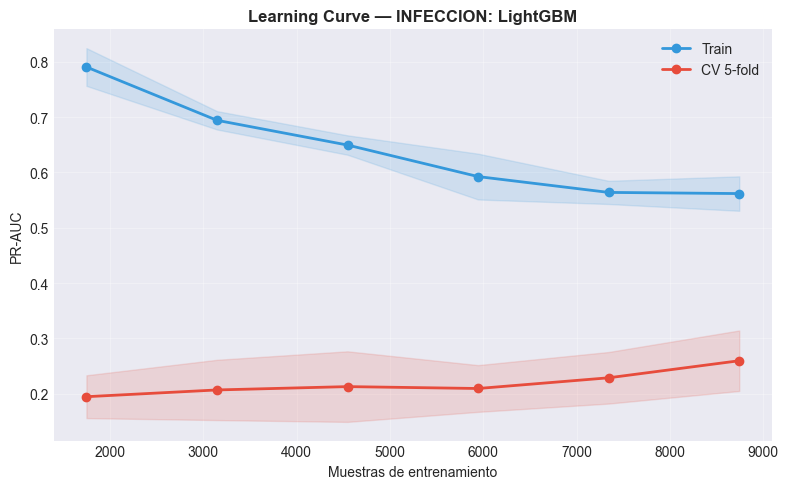

  LightGBM: gap=0.3021 (Overfitting) | CV PR-AUC=0.2598+/-0.0547


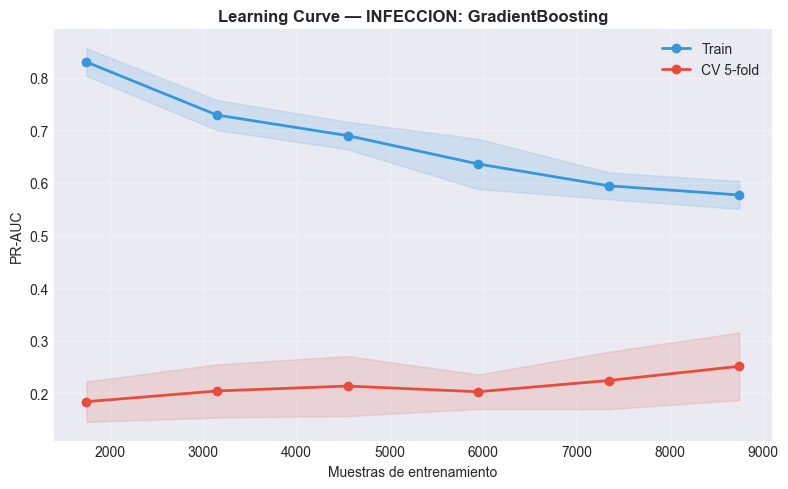

  GradientBoosting: gap=0.3262 (Overfitting) | CV PR-AUC=0.2509+/-0.0644


In [83]:
def plot_learning_curve_infeccion(modelo_nombre, X_raw, y_raw, cv=5):
    clase,params = MODELOS_CONFIG[modelo_nombre]
    ct_lc,_ = construir_preprocessor(X_raw.columns.tolist())
    try: modelo_inst=clase(**params,random_state=SEED)
    except TypeError: modelo_inst=clase(**params)
    pipeline = ImbPipeline([('preprocessor',ct_lc),
                            ('sampler',SAMPLER_CLASS(random_state=SEED,sampling_strategy=0.3)),
                            ('model',modelo_inst)])
    ts_abs,train_sc,val_sc = sk_learning_curve(
        pipeline,X_raw,y_raw,train_sizes=np.linspace(0.20,1.0,6),
        cv=StratifiedKFold(n_splits=cv,shuffle=True,random_state=SEED),
        scoring='average_precision',n_jobs=1)
    tr_m,tr_s = np.mean(train_sc,axis=1),np.std(train_sc,axis=1)
    cv_m,cv_s = np.mean(val_sc,axis=1),np.std(val_sc,axis=1)
    plt.figure(figsize=(8,5))
    plt.plot(ts_abs,tr_m,'o-',color='#3498db',lw=2,label='Train')
    plt.fill_between(ts_abs,tr_m-tr_s,tr_m+tr_s,alpha=0.15,color='#3498db')
    plt.plot(ts_abs,cv_m,'o-',color='#e74c3c',lw=2,label=f'CV {cv}-fold')
    plt.fill_between(ts_abs,cv_m-cv_s,cv_m+cv_s,alpha=0.15,color='#e74c3c')
    plt.xlabel('Muestras de entrenamiento'); plt.ylabel('PR-AUC')
    plt.title(f'Learning Curve — INFECCION: {modelo_nombre}',fontweight='bold')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    gap=abs(tr_m[-1]-cv_m[-1])
    diag='Overfitting' if gap>0.10 else ('Underfitting' if cv_m[-1]<0.05 else 'OK')
    print(f'  {modelo_nombre}: gap={gap:.4f} ({diag}) | CV PR-AUC={cv_m[-1]:.4f}+/-{cv_s[-1]:.4f}')

print('Calculando learning curves (puede tardar varios minutos)...')
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    plot_learning_curve_infeccion(info['modelo'],X_train,y_train)

---
## FASE 6: INTERPRETABILIDAD SHAP + CALIBRACION

- **TreeExplainer**: rapido y exacto para modelos de arboles (XGBoost, RF, GBM, ExtraTrees, LightGBM).
- **KernelExplainer**: universal pero lento; se subsamplea a 300 obs para GaussianNB/LogisticRegression.

In [84]:
TREE_MODELS = ['XGBoost','GradientBoosting','RandomForest','ExtraTrees','LightGBM']
SHAP_MAX_SAMPLES = 300

shap_modelos = {}
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    nombre=info['modelo']
    modelo_base=gs_results[nombre]['best_model']
    preprocessor=gs_results[nombre]['preprocessor']
    cols_out=gs_results[nombre]['cols_out']
    X_test_proc=gs_results[nombre]['X_test_scaled']
    X_train_proc=pd.DataFrame(preprocessor.transform(X_train),columns=cols_out)
    shap_modelos[rank]={'modelo':modelo_base,'X_train_scaled':X_train_proc,
                        'X_test_scaled':X_test_proc,'nombre':nombre,'rank':rank}
print(f"Modelos para SHAP ({len(shap_modelos)}): {[v['nombre'] for v in shap_modelos.values()]}")

Modelos para SHAP (2): ['LightGBM', 'GradientBoosting']


In [101]:
def calcular_shap_values(modelo, X_train_sample, X_test, modelo_tipo):
    print(f'\nCalculando SHAP para {modelo_tipo}...')
    if modelo_tipo in TREE_MODELS:
        explainer=shap.TreeExplainer(modelo); shap_values=explainer.shap_values(X_test); X_test_shap=X_test
    else:
        if len(X_test)>SHAP_MAX_SAMPLES:
            idx=np.random.RandomState(SEED).choice(len(X_test),SHAP_MAX_SAMPLES,replace=False)
            X_test_shap=X_test.iloc[idx].reset_index(drop=True)
            print(f'  Subsampled: {len(X_test)} -> {SHAP_MAX_SAMPLES} muestras')
        else: X_test_shap=X_test
        predict_fn=lambda X: modelo.predict_proba(np.array(X))[:,1]
        X_bg=shap.sample(X_train_sample,min(100,len(X_train_sample)))
        explainer=shap.KernelExplainer(predict_fn,X_bg)
        shap_values=explainer.shap_values(X_test_shap)
    if isinstance(shap_values,list): shap_values=shap_values[1]
    elif len(shap_values.shape)==3: shap_values=shap_values[:,:,1]
    print(f'  ✓ Shape: {shap_values.shape}')
    return explainer,shap_values,X_test_shap

shap_results = {}
for rank,data in shap_modelos.items():
    explainer,sv,X_te_shap=calcular_shap_values(data['modelo'],data['X_train_scaled'],data['X_test_scaled'],data['nombre'])
    shap_results[rank]={'explainer':explainer,'shap_values':sv,'X_test_scaled':X_te_shap,'nombre':data['nombre'],'rank':rank}
print(f'\n✓ SHAP calculado para {len(shap_results)} modelos')


Calculando SHAP para LightGBM...
  ✓ Shape: (2733, 42)

Calculando SHAP para GradientBoosting...
  ✓ Shape: (2733, 42)

✓ SHAP calculado para 2 modelos



TOP 15 VARIABLES — INFECCION (LightGBM)
                Variable  SHAP_Importance  % Total
           ASA_Anestesia         0.458632    17.05
           tumor_maligno         0.412246    15.33
    dm_sin_dano_organico         0.273363    10.16
 enf_cardiaca_congestiva         0.198816     7.39
                    epoc         0.143967     5.35
           vital_ta_sist         0.142808     5.31
           cirugia_mayor         0.129613     4.82
                    edad         0.126311     4.70
               enf_renal         0.117766     4.38
                    sexo         0.094794     3.52
tumor_solido_metastasico         0.081520     3.03
       anestesia_general         0.067076     2.49
            duracion_min         0.064219     2.39
  anestesia_locoregional         0.061359     2.28
                vital_fc         0.061010     2.27

TOP 15 VARIABLES — INFECCION (GradientBoosting)
                Variable  SHAP_Importance  % Total
           tumor_maligno         0.431526  

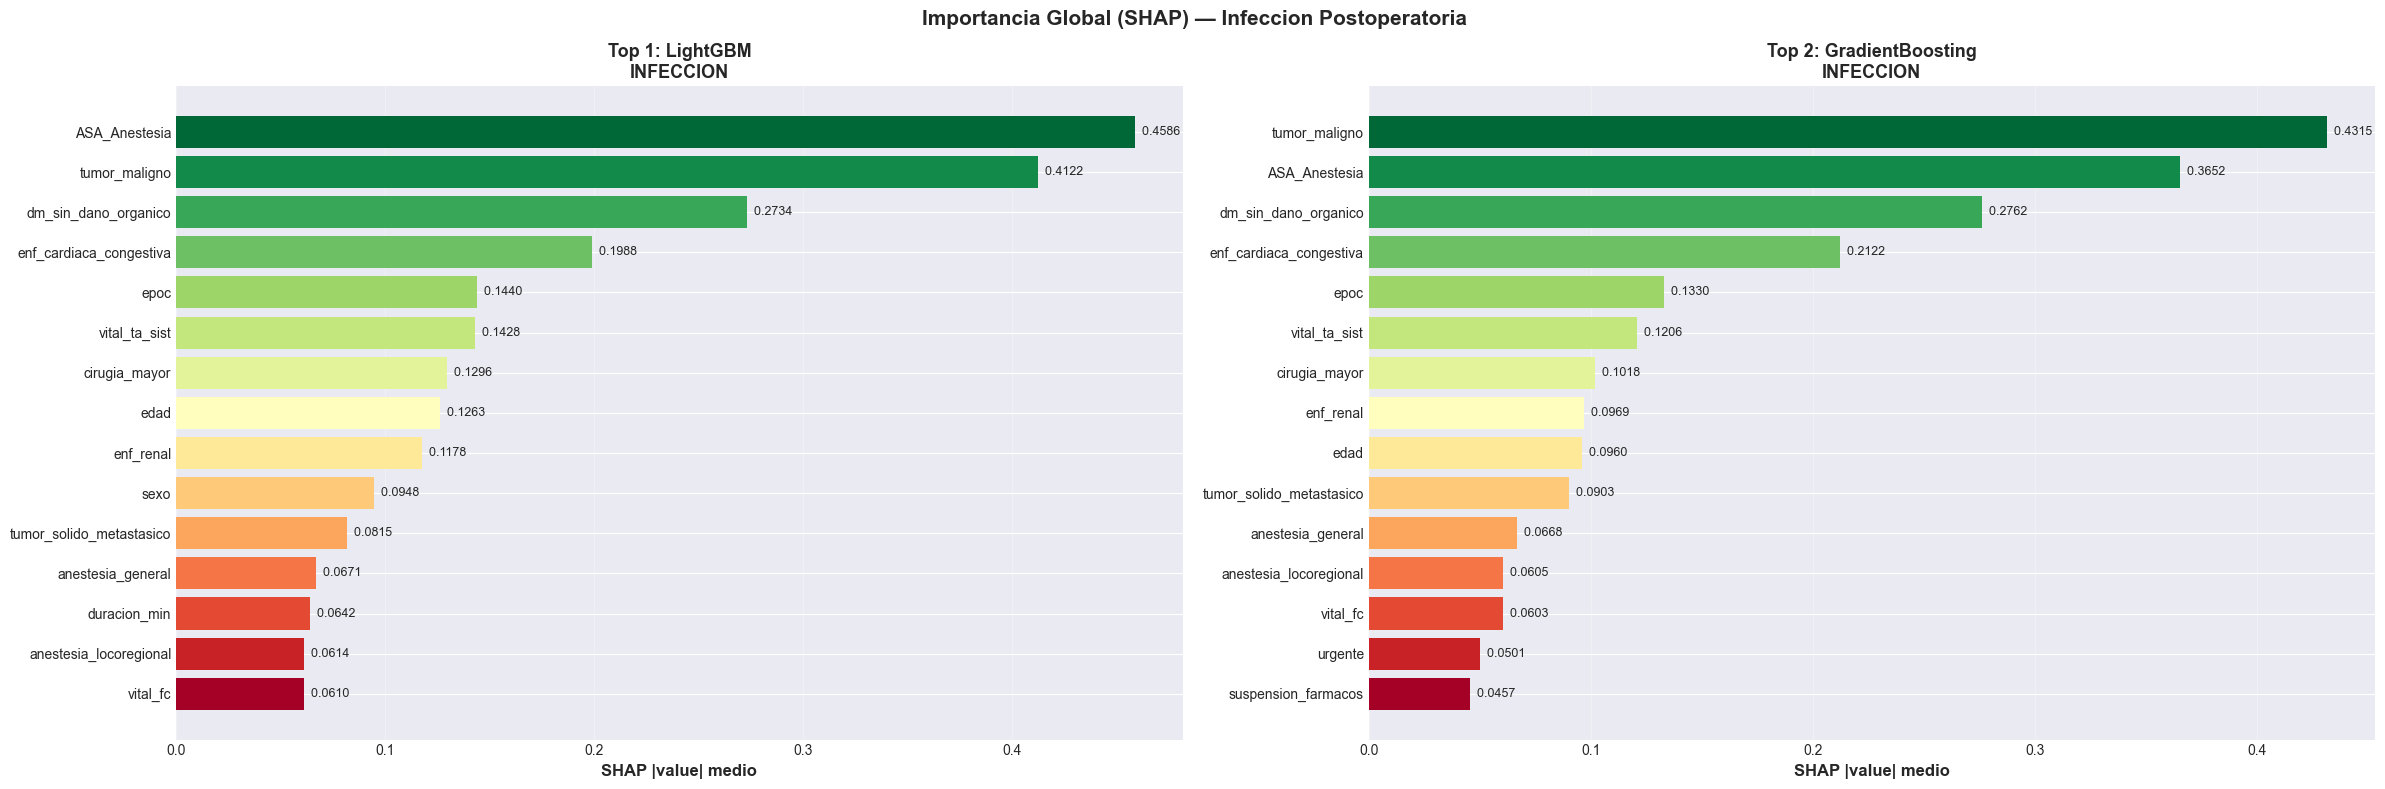

In [86]:
importancia_dict = {}
keys_shap=list(shap_results.keys()); n_models=len(keys_shap)
fig,axes=plt.subplots(1,max(n_models,1),figsize=(12*n_models,8))
if n_models==1: axes=[axes]
for i,rank in enumerate(keys_shap):
    sr=shap_results[rank]
    sv=sr['shap_values'][:,:,1] if len(sr['shap_values'].shape)==3 else sr['shap_values']
    importancia=np.abs(sv).mean(axis=0)
    df_imp=pd.DataFrame({'Variable':sr['X_test_scaled'].columns,'SHAP_Importance':importancia})
    df_imp=df_imp.sort_values('SHAP_Importance',ascending=False)
    df_imp['% Total']=(df_imp['SHAP_Importance']/df_imp['SHAP_Importance'].sum()*100).round(2)
    importancia_dict[rank]=df_imp
    print(f"\n{'='*80}\nTOP 15 VARIABLES — INFECCION ({sr['nombre']})\n{'='*80}")
    print(df_imp.head(15).to_string(index=False))
    ax=axes[i]; top=df_imp.head(15)
    colors_b2=plt.cm.RdYlGn_r(np.linspace(0,1,len(top)))
    bars=ax.barh(range(len(top)),top['SHAP_Importance'].values,color=colors_b2)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Variable'].values,fontsize=10)
    ax.set_xlabel('SHAP |value| medio',fontsize=12,fontweight='bold')
    rank_l='Top 1' if rank=='top1' else 'Top 2'
    ax.set_title(f'{rank_l}: {sr["nombre"]}\nINFECCION',fontsize=13,fontweight='bold'); ax.invert_yaxis()
    for bar,val in zip(bars,top['SHAP_Importance'].values):
        ax.text(val,bar.get_y()+bar.get_height()/2,f'  {val:.4f}',ha='left',va='center',fontsize=9)
    ax.grid(axis='x',alpha=0.3)
plt.suptitle('Importancia Global (SHAP) — Infeccion Postoperatoria',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.show()


SHAP Summary Plot — INFECCION — Top 1: LightGBM


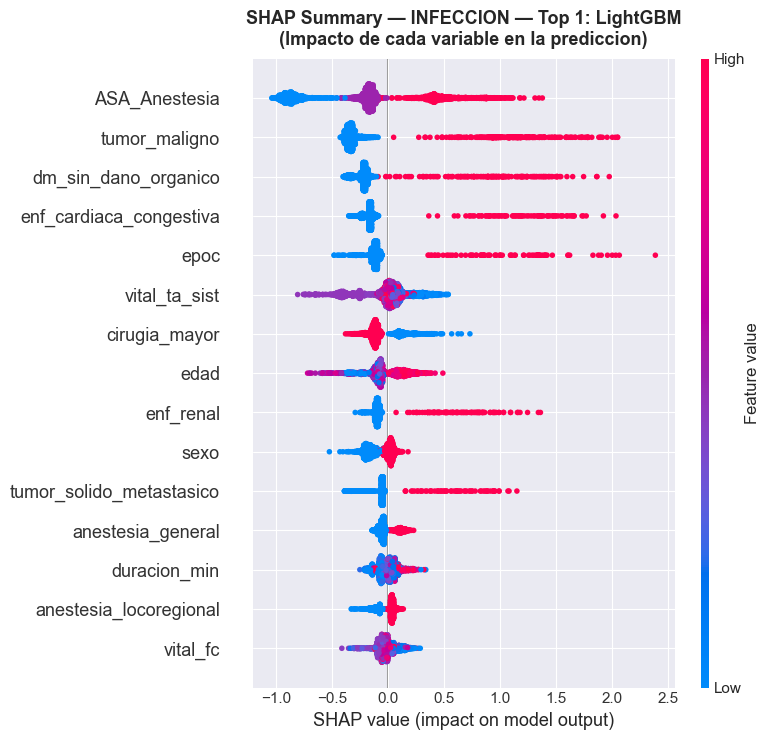


SHAP Summary Plot — INFECCION — Top 2: GradientBoosting


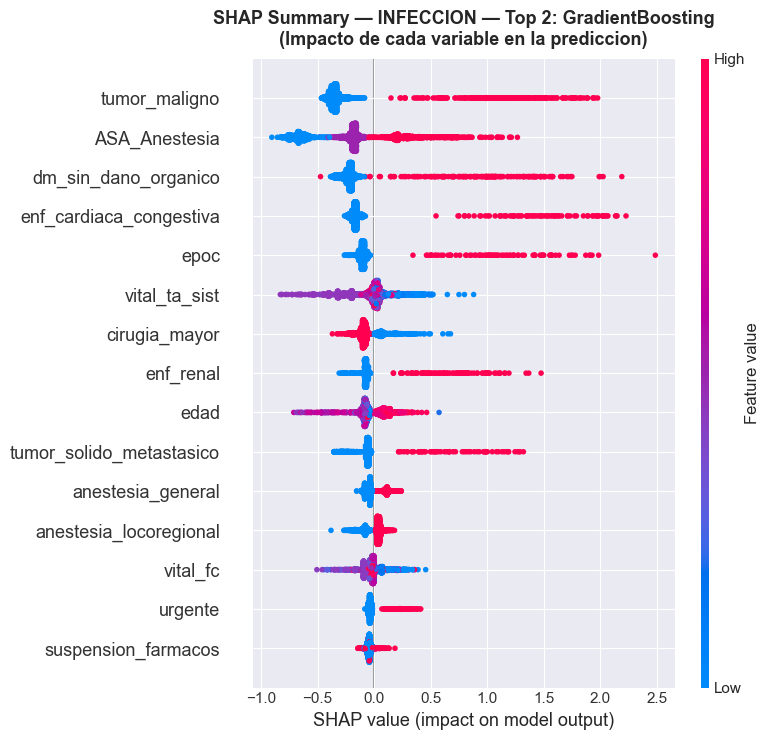

In [87]:
for rank,sr in shap_results.items():
    sv=sr['shap_values']; sv_plot=sv[:,:,1] if len(sv.shape)==3 else sv
    rank_l='Top 1' if rank=='top1' else 'Top 2'
    print(f"\nSHAP Summary Plot — INFECCION — {rank_l}: {sr['nombre']}")
    plt.figure(figsize=(14,8))
    shap.summary_plot(sv_plot,sr['X_test_scaled'],plot_type='dot',show=False,max_display=15)
    plt.title(f"SHAP Summary — INFECCION — {rank_l}: {sr['nombre']}\n(Impacto de cada variable en la prediccion)",
              fontsize=13,fontweight='bold',pad=10)
    plt.tight_layout(); plt.show()

### Curvas de Calibracion

SMOTEENN entrena con ~30% de positivos -> suele sobreestimar probabilidades (prevalencia real 3.02%).

**Brier Score**: MSE de probabilidades — 0 = perfecto, <0.10 excelente, <0.25 aceptable.

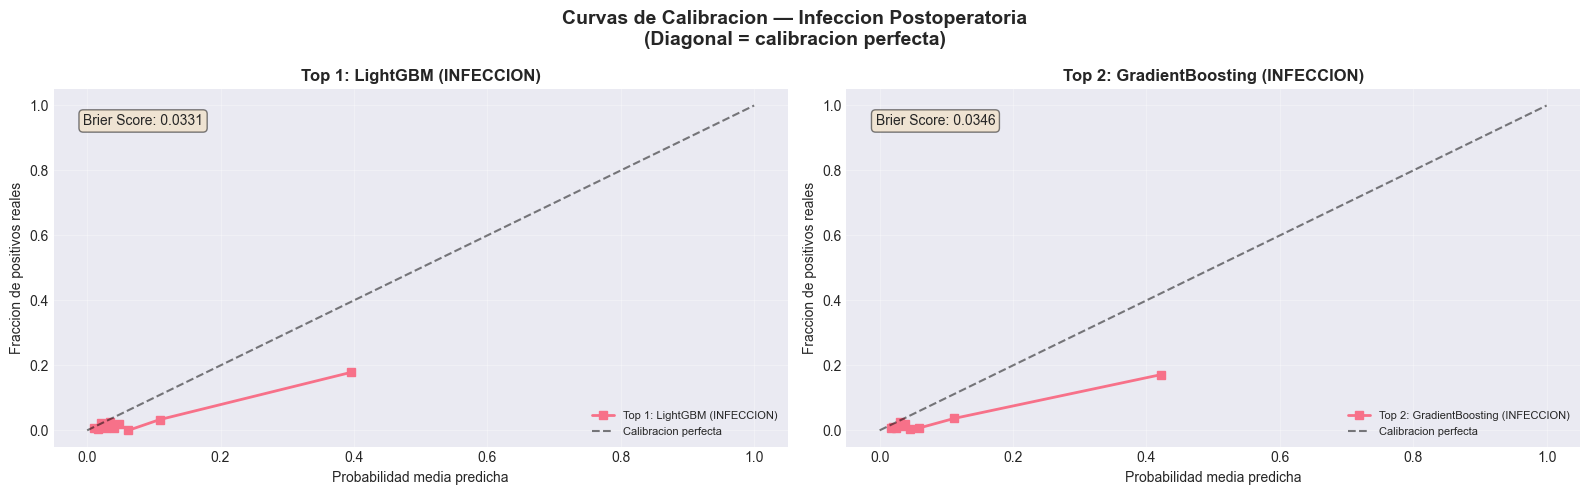

In [88]:
def plot_calibration(y_true, y_proba, label, ax):
    prob_true,prob_pred=calibration_curve(y_true,y_proba,n_bins=10,strategy='quantile')
    ax.plot(prob_pred,prob_true,'s-',lw=2,label=label)
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Calibracion perfecta')
    brier=brier_score_loss(y_true,y_proba)
    ax.text(0.04,0.90,f'Brier Score: {brier:.4f}',transform=ax.transAxes,fontsize=10,
            bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
    ax.set_xlabel('Probabilidad media predicha'); ax.set_ylabel('Fraccion de positivos reales')
    ax.set_title(label,fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

n_top=sum(1 for r in ['top1','top2'] if mejor_final.get(r) is not None)
fig,axes=plt.subplots(1,n_top,figsize=(8*n_top,5))
if n_top==1: axes=[axes]
i_ax=0
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    nombre=info['modelo']; y_proba=gs_results[nombre]['y_pred_proba']
    rank_l='Top 1' if rank=='top1' else 'Top 2'
    plot_calibration(y_test,y_proba,f'{rank_l}: {nombre} (INFECCION)',axes[i_ax]); i_ax+=1
plt.suptitle('Curvas de Calibracion — Infeccion Postoperatoria\n(Diagonal = calibracion perfecta)',
             fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()

top1 (LightGBM): Brier original=0.0322 -> recalibrado=0.0261
top2 (GradientBoosting): Brier original=0.0340 -> recalibrado=0.0266


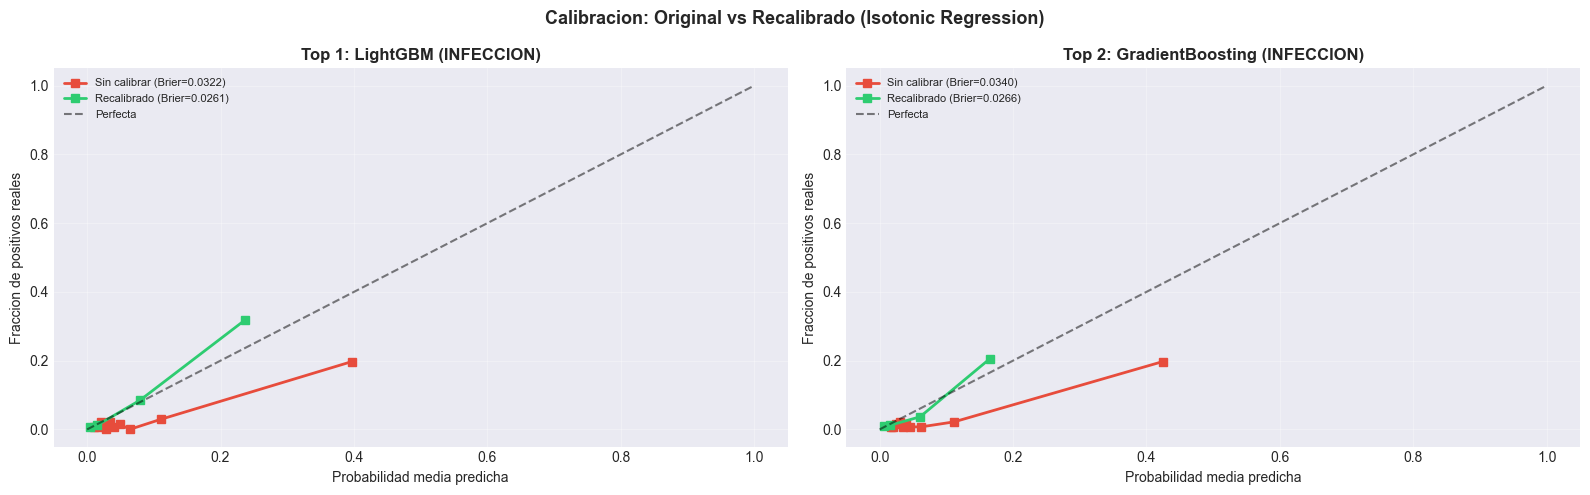


✓ Recalibracion completada.


In [89]:
# Recalibracion isotonica: particion 50/50 estratificada del test
# 50% para calibrar, 50% para evaluar (evita calibracion circular)
calibrated_results = {}
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    nombre=info['modelo']
    modelo_base=shap_modelos[rank]['modelo']; X_te_scaled=shap_modelos[rank]['X_test_scaled']
    y_proba_orig=gs_results[nombre]['y_pred_proba']
    cal_idx,eval_idx=train_test_split(np.arange(len(y_test)),test_size=0.5,stratify=y_test.values,random_state=SEED)
    X_cal_set=X_te_scaled.iloc[cal_idx]; X_eval_set=X_te_scaled.iloc[eval_idx]
    y_cal_set=y_test.iloc[cal_idx]; y_eval_set=y_test.iloc[eval_idx]
    y_proba_orig_eval=y_proba_orig[eval_idx]
    _proba_cal_raw=modelo_base.predict_proba(X_cal_set)[:,1]
    cal=IsotonicRegression(out_of_bounds='clip'); cal.fit(_proba_cal_raw,y_cal_set)
    y_proba_cal=cal.predict(modelo_base.predict_proba(X_eval_set)[:,1])
    brier_orig=brier_score_loss(y_eval_set,y_proba_orig_eval)
    brier_cal=brier_score_loss(y_eval_set,y_proba_cal)
    calibrated_results[rank]={'y_proba_cal':y_proba_cal,'y_proba_orig':y_proba_orig_eval,
        'calibrator':cal,'brier_orig':brier_orig,'brier_cal':brier_cal,'y_eval_set':y_eval_set}
    print(f'{rank} ({nombre}): Brier original={brier_orig:.4f} -> recalibrado={brier_cal:.4f}')

n_top=sum(1 for r in ['top1','top2'] if mejor_final.get(r) is not None)
fig,axes=plt.subplots(1,n_top,figsize=(8*n_top,5))
if n_top==1: axes=[axes]
i_ax=0
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    nombre=info['modelo']; ax=axes[i_ax]; y_eval=calibrated_results[rank]['y_eval_set']
    for y_p,lbl,col in [(calibrated_results[rank]['y_proba_orig'],'Sin calibrar','#e74c3c'),
                         (calibrated_results[rank]['y_proba_cal'],'Recalibrado','#2ecc71')]:
        p_true,p_pred=calibration_curve(y_eval,y_p,n_bins=10,strategy='quantile')
        brier=brier_score_loss(y_eval,y_p)
        ax.plot(p_pred,p_true,'s-',lw=2,label=f'{lbl} (Brier={brier:.4f})',color=col)
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfecta')
    rank_l='Top 1' if rank=='top1' else 'Top 2'
    ax.set_title(f'{rank_l}: {nombre} (INFECCION)',fontweight='bold')
    ax.set_xlabel('Probabilidad media predicha'); ax.set_ylabel('Fraccion de positivos reales')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); i_ax+=1
plt.suptitle('Calibracion: Original vs Recalibrado (Isotonic Regression)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show(); print('\n✓ Recalibracion completada.')

### SHAP Dependence Plots

Relaciones no lineales entre cada feature y su contribucion a la prediccion de infeccion.
Color = feature de interaccion auto-seleccionada por SHAP.

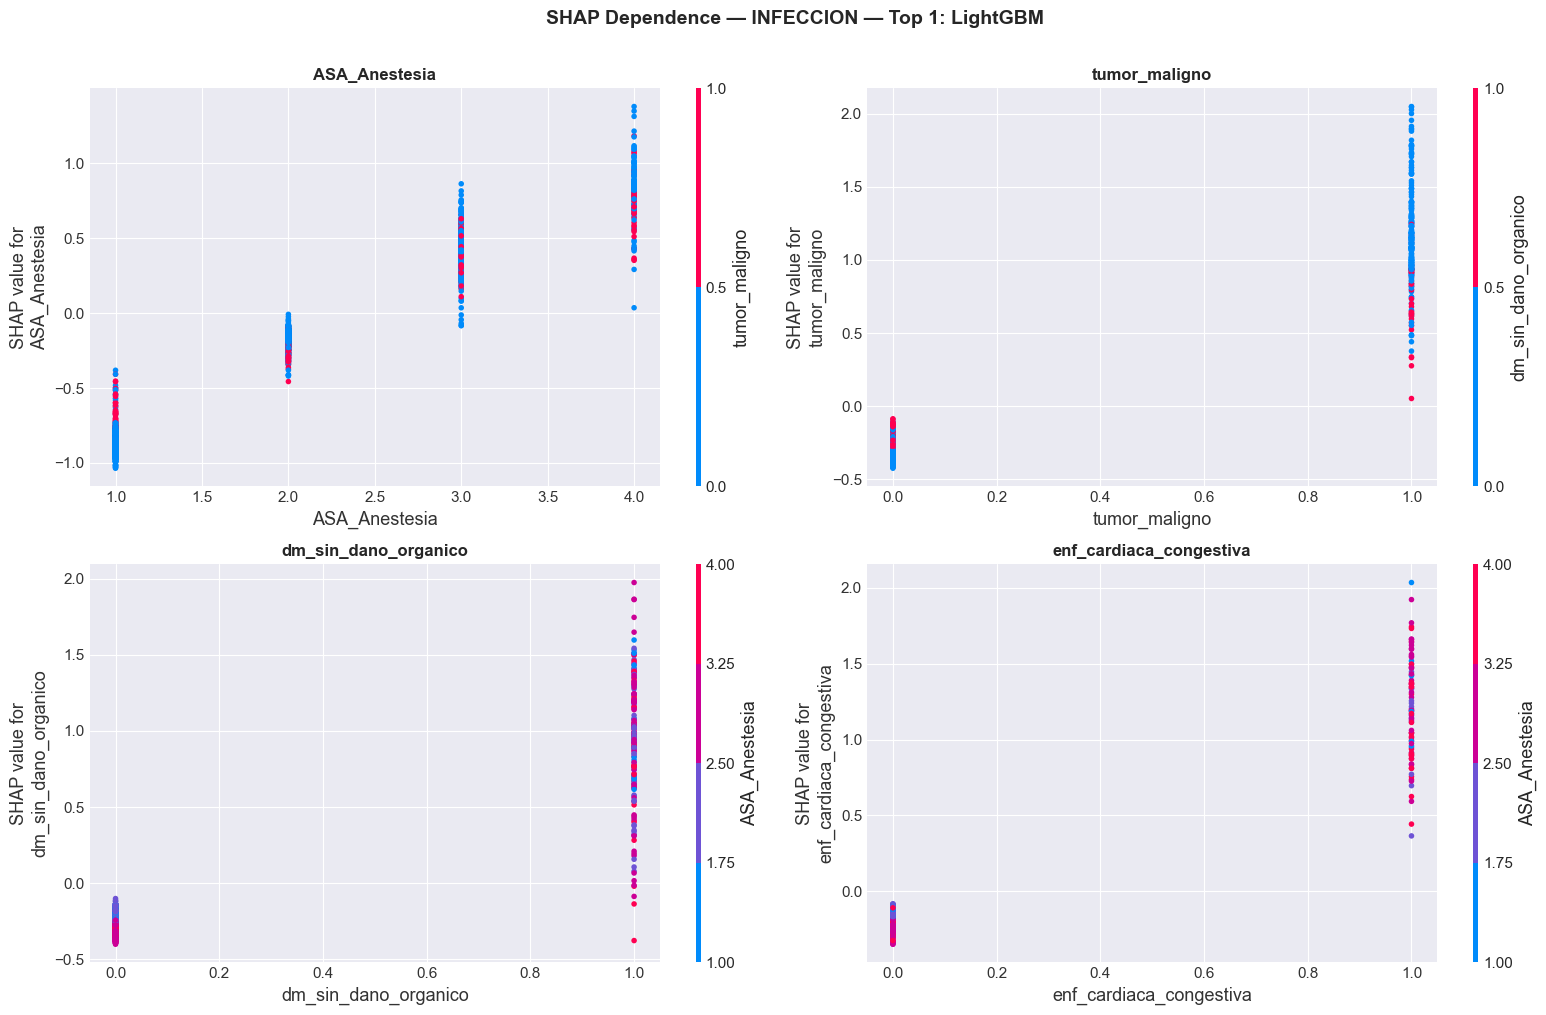

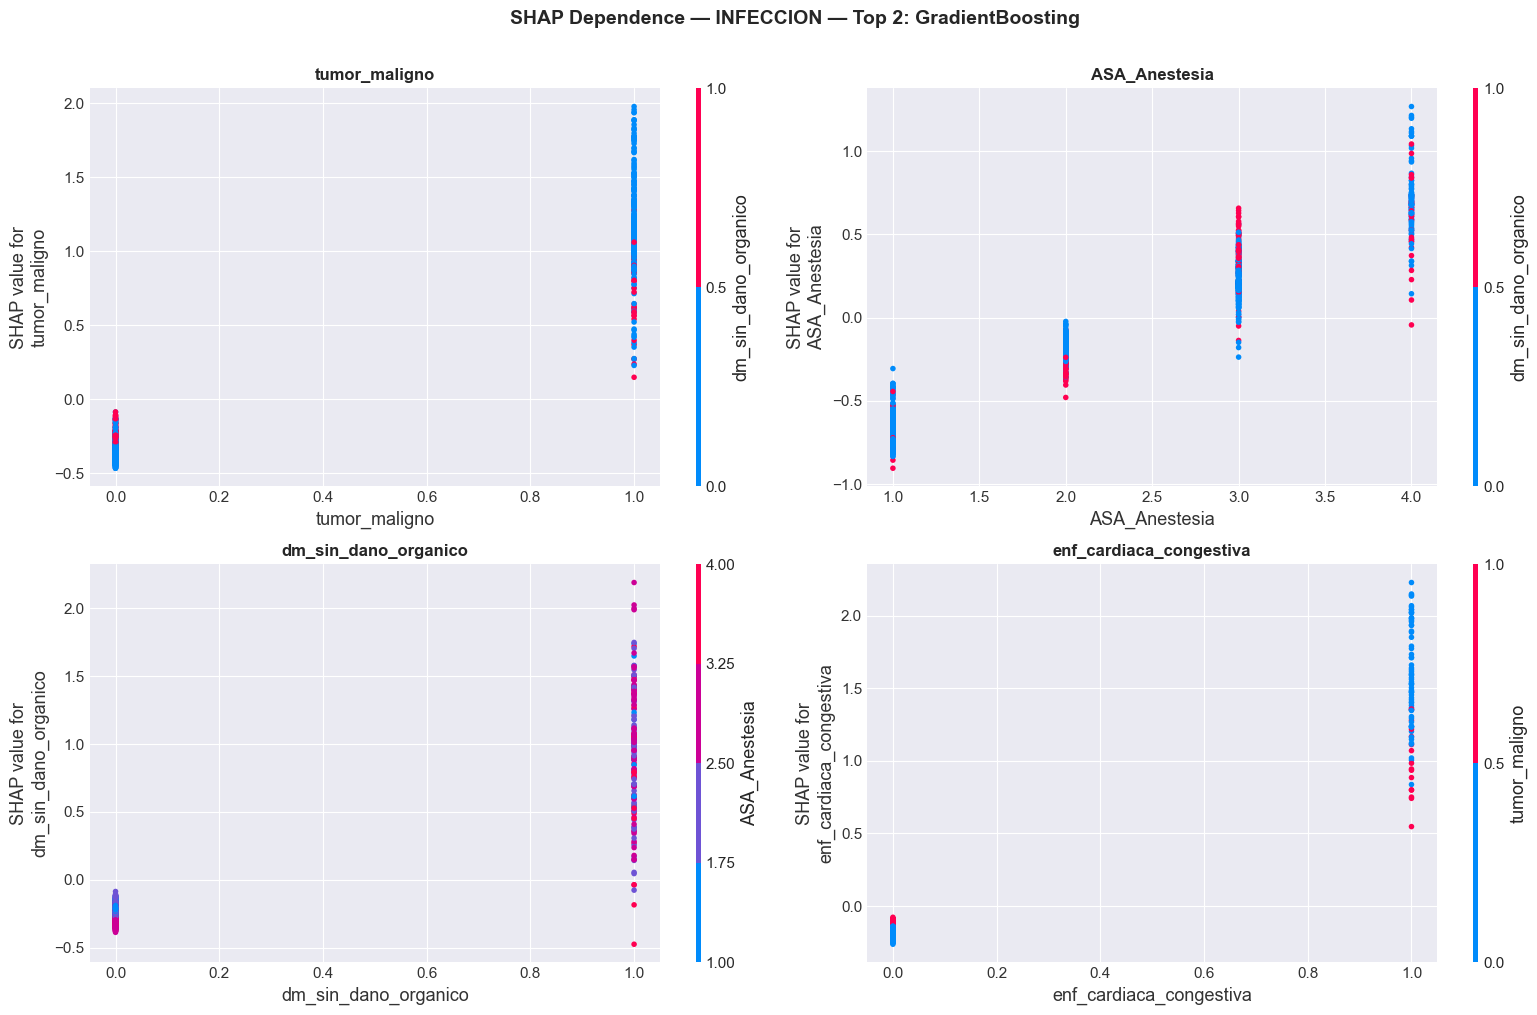

In [90]:
def dependence_plots(shap_values, X_test, importancia_df, modelo_nombre, rank_label, top_n=4):
    sv=shap_values[:,:,1] if len(shap_values.shape)==3 else shap_values
    top_features=importancia_df.head(top_n)['Variable'].tolist()
    fig,axes=plt.subplots(2,2,figsize=(16,10)); axes_flat=axes.flatten()
    for idx,feature in enumerate(top_features):
        ax=axes_flat[idx]; plt.sca(ax)
        shap.dependence_plot(feature,sv,X_test,ax=ax,show=False)
        ax.set_title(f'{feature}',fontsize=12,fontweight='bold')
    plt.suptitle(f'SHAP Dependence — INFECCION — {rank_label}: {modelo_nombre}',
                fontsize=14,fontweight='bold',y=1.01)
    plt.tight_layout(); plt.show()

for rank in shap_results:
    sr=shap_results[rank]; rank_label='Top 1' if rank=='top1' else 'Top 2'
    dependence_plots(sr['shap_values'],sr['X_test_scaled'],importancia_dict[rank],sr['nombre'],rank_label)

---
## FASE 7: EXPORTACION DE RESULTADOS

In [91]:
df_comparativa.to_csv('results/tabla_comparativa_infeccion.csv',index=False)
print('✓ Tabla comparativa guardada: results/tabla_comparativa_infeccion.csv')

fold_rows=[]
for nombre,res in kfold_results.items():
    fold_prauc=res['fold_metrics']['pr_auc']
    row={'Target':'INFECCION','Modelo':nombre,'Tecnica':BEST_TECNICA}
    for k,v in enumerate(fold_prauc,1): row[f'fold_{k}']=round(v,6)
    fold_rows.append(row)
df_folds_export=pd.DataFrame(fold_rows)
_folds_csv = f'results/tabla_folds_infeccion_{BEST_TECNICA}.csv'
df_folds_export.to_csv(_folds_csv,index=False)
print(f'✓ Fold PR-AUC guardado: {_folds_csv} ({len(df_folds_export)} filas)')

print(f'\n{"="*70}\nRESUMEN FINAL — INFECCION POSTOPERATORIA\n{"="*70}')
print(f'  Dataset         : {len(X_raw):,} pacientes (Poblacion Diana Osakidetza)')
print(f'  Features        : {len(ALL_FEATS)} (31 orig + 10 quirurgicas/vitales)')
print(f'  Positivos (test): {y_test.sum()} ({y_test.mean()*100:.2f}%)')
print(f'  Tecnica balanceo: {BEST_TECNICA} (seleccionada automaticamente en Fase 1b)')
print()
for rank in ['top1','top2']:
    info=mejor_final.get(rank)
    if info is None: continue
    rank_l='Top 1' if rank=='top1' else 'Top 2'
    print(f"  {rank_l}: {info['modelo']} — PR-AUC={info['pr_auc']:.4f} | AUC-ROC={info['auc_roc']:.4f} | Recall={info['recall']:.4f}")
    ci=bootstrap_results.get(rank,{})
    if ci: print(f"         IC 95%: PR-AUC=[{ci['pr_auc_lo']:.4f}-{ci['pr_auc_hi']:.4f}] | AUC-ROC=[{ci['auc_roc_lo']:.4f}-{ci['auc_roc_hi']:.4f}]")


✓ Tabla comparativa guardada: results/tabla_comparativa_infeccion.csv
✓ Fold PR-AUC guardado: results/tabla_folds_infeccion_SMOTEENN.csv (7 filas)

RESUMEN FINAL — INFECCION POSTOPERATORIA
  Dataset         : 13,661 pacientes (Poblacion Diana Osakidetza)
  Features        : 42 (31 orig + 10 quirurgicas/vitales)
  Positivos (test): 83 (3.04%)
  Tecnica balanceo: SMOTEENN (seleccionada automaticamente en Fase 1b)

  Top 1: LightGBM — PR-AUC=0.2472 | AUC-ROC=0.7881 | Recall=0.3012
         IC 95%: PR-AUC=[0.1583-0.3526] | AUC-ROC=[0.7252-0.8472]
  Top 2: GradientBoosting — PR-AUC=0.2446 | AUC-ROC=0.7851 | Recall=0.3253
         IC 95%: PR-AUC=[0.1535-0.3529] | AUC-ROC=[0.7218-0.8450]


---
## FASE 9: PREDICCIÓN MULTICLASE — TIPO DE INFECCIÓN

Una vez identificado si existe infección, el siguiente problema clínico es **¿qué tipo de infección es?**.

### Variable objetivo: `categoria_infeccion`
| Clase | Descripción | N |
|---|---|---|
| `ninguna` | Sin infección postoperatoria | 13,249 |
| `resp` | Infección respiratoria | 193 |
| `sepsis` | Sepsis/bacteriemia | 67 |
| `itu` | Infección tracto urinario | 53 |
| `ssi` | Infección herida quirúrgica | 40 |
| `cateter` | Infección relacionada con catéter | 35 |
| `other` | Otras infecciones | 25 |

### Estrategia
1. **Modelo 7-clases (global)**: predice `categoria_infeccion` sobre los 13,662 pacientes.
   Útil para cribado conjunto — un solo modelo detecta infección *y* su tipo.
2. **Modelo condicional (6 clases)**: predice el tipo *sólo entre los 413 infectados*.
   Más preciso para apoyo a decisión clínica cuando ya se sospecha infección.

**Manejo del desequilibrio**: `RandomOverSampler` con `sampling_strategy='not majority'`
(soporta multiclase a diferencia de SMOTEENN) + `class_weight='balanced'` en los modelos.

**Métricas**: F1 macro (peso igual para todas las clases, penaliza infra-clasificación de clases raras),
F1 weighted (distribución real), accuracy, y classification report completo.


In [92]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ─── Cargar variable multiclase alineada por id_paciente ─────────────────────
# X_raw tiene 13,661 filas (post-deduplicación); el CSV tiene 13,662 → alinear por id
y_cat_df = pd.read_csv('results/y_infeccion_postop.csv')[['id_paciente', 'categoria_infeccion']]
y_cat_df['id'] = y_cat_df['id_paciente'].astype(str).str.strip()

# Merge con X_base (mismo orden y pacientes que X_raw) por columna 'id'
y_cat_aligned = X_base[['id']].merge(y_cat_df[['id', 'categoria_infeccion']], on='id', how='left')
y_cat_series = y_cat_aligned['categoria_infeccion'].reset_index(drop=True)

assert y_cat_series.isna().sum() == 0, f'NaN en categoria_infeccion: {y_cat_series.isna().sum()}'
assert len(y_cat_series) == len(X_raw), f'Desalineación: {len(y_cat_series)} vs {len(X_raw)}'
print(f'Filas alineadas: {len(y_cat_series):,}')
print(f'Categorías únicas: {sorted(y_cat_series.unique())}')

# ─── Codificación preservando orden clínico ───────────────────────────────────
# Codificación manual: ninguna=0, resp=1, sepsis=2, itu=3, ssi=4, cateter=5, other=6
ORDEN_CLASES = ['ninguna', 'resp', 'sepsis', 'itu', 'ssi', 'cateter', 'other']
_cat_to_int = {c: i for i, c in enumerate(ORDEN_CLASES)}
y_cat_enc = y_cat_series.map(_cat_to_int).values.astype(int)

# le_cat.classes_ para decodificación (le_cat.classes_[i] → nombre de clase)
le_cat = LabelEncoder()
le_cat.classes_ = np.array(ORDEN_CLASES)   # sólo se usa como lookup, no para fit

# ─── Mismo split que clasificación binaria (train_idx / test_idx de Fase 1) ──
# ANTI-LEAKAGE: usar los mismos índices garantiza que los pacientes en test son
# exactamente los mismos para el modelo binario y los multiclase → no hay
# contaminación cruzada entre los conjuntos de entrenamiento y evaluación.
X_train_mc = X_raw.iloc[train_idx].reset_index(drop=True)
X_test_mc  = X_raw.iloc[test_idx].reset_index(drop=True)
y_train_mc = y_cat_enc[train_idx]
y_test_mc  = y_cat_enc[test_idx]

print('Dataset multiclase (7 clases):')
print(f'  Train: {len(X_train_mc):,}  |  Test: {len(X_test_mc):,}')
print('\n  Distribución train:')
unique, counts = np.unique(y_train_mc, return_counts=True)
for u, c in zip(unique, counts):
    print(f'    {ORDEN_CLASES[u]:<12}: {c:>5} ({c/len(y_train_mc)*100:.2f}%)')
print('\n  Distribución test:')
unique_t, counts_t = np.unique(y_test_mc, return_counts=True)
for u, c in zip(unique_t, counts_t):
    print(f'    {ORDEN_CLASES[u]:<12}: {c:>5} ({c/len(y_test_mc)*100:.2f}%)')


Filas alineadas: 13,661
Categorías únicas: ['cateter', 'itu', 'ninguna', 'other', 'resp', 'sepsis', 'ssi']
Dataset multiclase (7 clases):
  Train: 10,928  |  Test: 2,733

  Distribución train:
    ninguna     : 10598 (96.98%)
    resp        :   150 (1.37%)
    sepsis      :    57 (0.52%)
    itu         :    44 (0.40%)
    ssi         :    31 (0.28%)
    cateter     :    33 (0.30%)
    other       :    15 (0.14%)

  Distribución test:
    ninguna     :  2650 (96.96%)
    resp        :    43 (1.57%)
    sepsis      :    10 (0.37%)
    itu         :     9 (0.33%)
    ssi         :     9 (0.33%)
    cateter     :     2 (0.07%)
    other       :    10 (0.37%)


In [93]:
from sklearn.metrics import f1_score as f1_score_sk

# ─── Modelos multiclase nativos ─────────────────────────────────────────────
MODELOS_MC = {
    'XGBoost': xgb.XGBClassifier(
        random_state=SEED, eval_metric='mlogloss', n_jobs=1,
        num_class=7,
        objective='multi:softprob',
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=SEED, verbose=-1, n_jobs=1,
        objective='multiclass', num_class=7, class_weight='balanced',
    ),
    'RandomForest': RandomForestClassifier(
        random_state=SEED, n_jobs=1, class_weight='balanced', n_estimators=200,
    ),
}

# ─── GridSearch reducido para multiclase ─────────────────────────────────────
PARAM_GRIDS_MC = {
    'XGBoost':     {'model__n_estimators': [100, 200],
                    'model__max_depth': [3, 6],
                    'model__learning_rate': [0.05, 0.1]},
    'LightGBM':    {'model__n_estimators': [100, 200],
                    'model__max_depth': [3, 5],
                    'model__learning_rate': [0.05, 0.1],
                    'model__num_leaves': [15, 31]},
    'RandomForest':{'model__n_estimators': [100, 200],
                    'model__max_depth': [5, 10, None],
                    'model__min_samples_leaf': [1, 5]},
}

print('Modelos y grids multiclase definidos.')


Modelos y grids multiclase definidos.


In [94]:
def entrenar_mc_modelo(X_tr, y_tr, X_te, y_te, nombre, modelo, param_grid, cv=5):
    """GridSearch para modelo multiclase con RandomOverSampler + preprocesado."""
    preprocessor, _ = construir_preprocessor(X_tr.columns.tolist())
    sampler_mc = RandomOverSampler(random_state=SEED, sampling_strategy='not majority')
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler',       sampler_mc),
        ('model',         modelo),
    ])
    cv_strat = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    gs = GridSearchCV(pipeline, param_grid, cv=cv_strat,
                      scoring='f1_macro', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_tr)

    y_pred = gs.best_estimator_.predict(X_te)
    y_proba = gs.best_estimator_.predict_proba(X_te)   # shape (n, n_classes)

    f1_mac  = f1_score(y_te, y_pred, average='macro',    zero_division=0)
    f1_wei  = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    acc     = accuracy_score(y_te, y_pred)
    cm      = confusion_matrix(y_te, y_pred)
    report  = classification_report(y_te, y_pred,
                                    target_names=ORDEN_CLASES, zero_division=0)

    best_params = {k.replace('model__', ''): v for k, v in gs.best_params_.items()}
    print(f'\n  {nombre}: CV f1_macro={gs.best_score_:.4f} | test f1_macro={f1_mac:.4f} | f1_weighted={f1_wei:.4f} | acc={acc:.4f}')
    return {
        'nombre': nombre, 'cv_f1_macro': round(gs.best_score_, 4),
        'f1_macro': round(f1_mac, 4), 'f1_weighted': round(f1_wei, 4),
        'accuracy': round(acc, 4), 'confusion_matrix': cm,
        'classification_report': report, 'y_pred': y_pred, 'y_proba': y_proba,
        'best_params': best_params, 'best_pipeline': gs.best_estimator_,
    }

print('Función entrenar_mc_modelo definida.')


Función entrenar_mc_modelo definida.


In [95]:
print('=' * 100)
print('MODELO MULTICLASE — 7 CLASES (todos los pacientes)')
print('=' * 100)

_ck_mc = 'mc_7clases_infeccion.pkl'
mc_results = load_checkpoint(_ck_mc)

if mc_results is None:
    mc_results = {}
    for nombre, modelo in MODELOS_MC.items():
        print(f'\n[{nombre}]')
        t0 = time.time()
        mc_results[nombre] = entrenar_mc_modelo(
            X_train_mc, y_train_mc, X_test_mc, y_test_mc,
            nombre, modelo, PARAM_GRIDS_MC[nombre]
        )
        mc_results[nombre]['tiempo_seg'] = round(time.time() - t0, 1)
        print(f'  Tiempo: {mc_results[nombre]["tiempo_seg"]}s')
    save_checkpoint(mc_results, _ck_mc)
    print('\n✓ Modelos multiclase guardados en checkpoint.')
else:
    print('✓ Modelos multiclase cargados desde checkpoint.')

# ─── Tabla resumen ────────────────────────────────────────────────────────────
print('\n\nRESUMEN MODELOS MULTICLASE (7 clases):')
print(f"  {'Modelo':<16} {'F1 Macro':>10} {'F1 Weighted':>12} {'Accuracy':>10} {'CV f1_macro':>12}")
print('  ' + '─' * 62)
for nombre, res in sorted(mc_results.items(), key=lambda x: -x[1]['f1_macro']):
    print(f"  {nombre:<16} {res['f1_macro']:>10.4f} {res['f1_weighted']:>12.4f} {res['accuracy']:>10.4f} {res['cv_f1_macro']:>12.4f}")

# ─── Mejor modelo ─────────────────────────────────────────────────────────────
best_mc_nombre = max(mc_results, key=lambda n: mc_results[n]['f1_macro'])
best_mc = mc_results[best_mc_nombre]
print(f'\n✓ Mejor modelo: {best_mc_nombre} (F1 macro={best_mc["f1_macro"]:.4f})')
print(f'  Params: {best_mc["best_params"]}')


MODELO MULTICLASE — 7 CLASES (todos los pacientes)

[XGBoost]

  XGBoost: CV f1_macro=0.1918 | test f1_macro=0.1784 | f1_weighted=0.9405 | acc=0.9305
  Tiempo: 22.5s

[LightGBM]

  LightGBM: CV f1_macro=0.1963 | test f1_macro=0.1773 | f1_weighted=0.9108 | acc=0.8752
  Tiempo: 21.8s

[RandomForest]

  RandomForest: CV f1_macro=0.2099 | test f1_macro=0.1951 | f1_weighted=0.9584 | acc=0.9627
  Tiempo: 22.9s
  [CKPT] Guardado: results/checkpoints/mc_7clases_infeccion.pkl

✓ Modelos multiclase guardados en checkpoint.


RESUMEN MODELOS MULTICLASE (7 clases):
  Modelo             F1 Macro  F1 Weighted   Accuracy  CV f1_macro
  ──────────────────────────────────────────────────────────────
  RandomForest         0.1951       0.9584     0.9627       0.2099
  XGBoost              0.1784       0.9405     0.9305       0.1918
  LightGBM             0.1773       0.9108     0.8752       0.1963

✓ Mejor modelo: RandomForest (F1 macro=0.1951)
  Params: {'max_depth': None, 'min_samples_leaf': 5, 'n_est

CLASSIFICATION REPORT — RandomForest (7 clases)

              precision    recall  f1-score   support

     ninguna       0.98      0.99      0.98      2650
        resp       0.47      0.33      0.38        43
      sepsis       0.00      0.00      0.00        10
         itu       0.00      0.00      0.00         9
         ssi       0.00      0.00      0.00         9
     cateter       0.00      0.00      0.00         2
       other       0.00      0.00      0.00        10

    accuracy                           0.96      2733
   macro avg       0.21      0.19      0.20      2733
weighted avg       0.95      0.96      0.96      2733



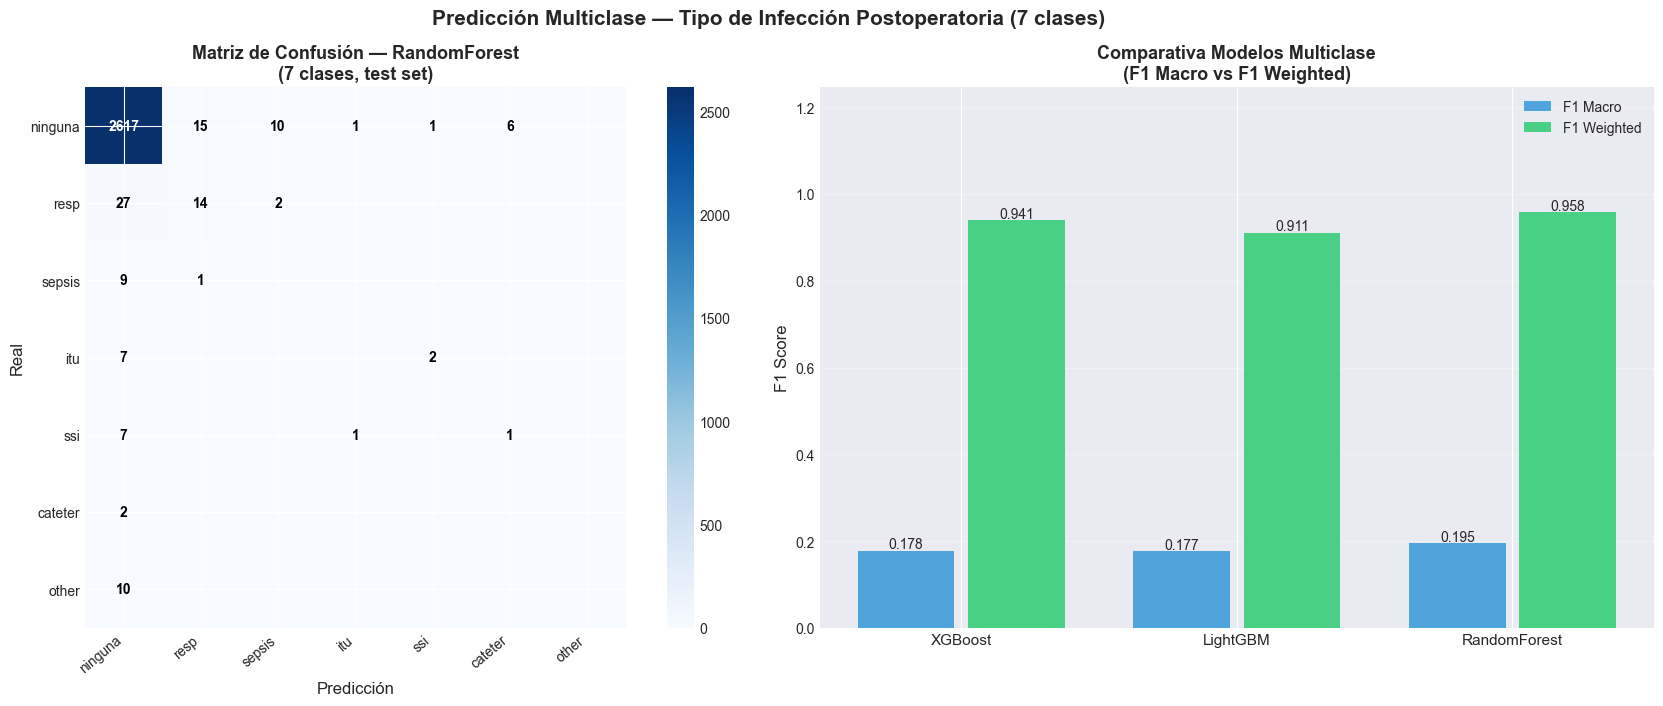

In [96]:
# ─── Classification report del mejor modelo ──────────────────────────────────
print(f'CLASSIFICATION REPORT — {best_mc_nombre} (7 clases)\n')
print(best_mc['classification_report'])

# ─── Matriz de confusión ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Mejor modelo — matriz de confusión
cm_best = best_mc['confusion_matrix']
im0 = axes[0].imshow(cm_best, cmap='Blues')
axes[0].set_xticks(range(len(ORDEN_CLASES))); axes[0].set_xticklabels(ORDEN_CLASES, rotation=40, ha='right')
axes[0].set_yticks(range(len(ORDEN_CLASES))); axes[0].set_yticklabels(ORDEN_CLASES)
axes[0].set_xlabel('Predicción', fontsize=12); axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title(f'Matriz de Confusión — {best_mc_nombre}\n(7 clases, test set)',
                  fontsize=13, fontweight='bold')
plt.colorbar(im0, ax=axes[0])
for i in range(len(ORDEN_CLASES)):
    for j in range(len(ORDEN_CLASES)):
        val = cm_best[i, j]
        if val > 0:
            axes[0].text(j, i, str(val), ha='center', va='center',
                         fontsize=10, fontweight='bold',
                         color='white' if val > cm_best.max() * 0.6 else 'black')

# Barras F1 macro por modelo
nombres_mc = list(mc_results.keys())
f1_macros  = [mc_results[n]['f1_macro'] for n in nombres_mc]
f1_weights = [mc_results[n]['f1_weighted'] for n in nombres_mc]
x_mc = np.arange(len(nombres_mc))
axes[1].bar(x_mc - 0.2, f1_macros,  0.35, label='F1 Macro',    color='#3498db', alpha=0.85)
axes[1].bar(x_mc + 0.2, f1_weights, 0.35, label='F1 Weighted', color='#2ecc71', alpha=0.85)
for xi, (vm, vw) in enumerate(zip(f1_macros, f1_weights)):
    axes[1].text(xi - 0.2, vm + 0.005, f'{vm:.3f}', ha='center', fontsize=10)
    axes[1].text(xi + 0.2, vw + 0.005, f'{vw:.3f}', ha='center', fontsize=10)
axes[1].set_xticks(x_mc); axes[1].set_xticklabels(nombres_mc, fontsize=11)
axes[1].set_ylim(0, max(max(f1_macros), max(f1_weights)) * 1.3)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Comparativa Modelos Multiclase\n(F1 Macro vs F1 Weighted)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Predicción Multiclase — Tipo de Infección Postoperatoria (7 clases)',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


### Fase 9b: Modelo condicional — clasificación del tipo de infección (sólo pacientes infectados)

Se entrena un segundo modelo usando únicamente los **413 pacientes con infección confirmada**.
Objetivo: predecir el tipo específico entre 6 categorías (se elimina la clase `ninguna`).

**Ventaja clínica**: en escenario real, este modelo se aplica *después* de que el modelo binario
detecte infección → mayor precisión en la clasificación del subtipo.

**Reto**: n=413 con clases muy desbalanceadas (resp=193 vs other=25).
Se aplica `class_weight='balanced'` + validación cruzada estratificada.


In [97]:
# ─── Subset: solo pacientes infectados (derivado del split multiclase) ───────
# Se reutilizan train_idx / test_idx de la Fase 1 → los tres modelos (binario,
# multiclase global, condicional) comparten exactamente el mismo test set.
# 'ninguna' tiene código 0 en ORDEN_CLASES; infectados tienen código 1..6.
ORDEN_CLASES_6 = ['resp', 'sepsis', 'itu', 'ssi', 'cateter', 'other']  # sin 'ninguna'

mask_tr_inf = (y_train_mc != 0)   # infectados en train
mask_te_inf = (y_test_mc  != 0)   # infectados en test

X_tr_c = X_train_mc[mask_tr_inf].reset_index(drop=True)
X_te_c = X_test_mc[mask_te_inf].reset_index(drop=True)

# Re-codificar: ORDEN_CLASES[1..6] → ORDEN_CLASES_6[0..5] (restar 1)
y_tr_c = (y_train_mc[mask_tr_inf] - 1).astype(int)
y_te_c = (y_test_mc[mask_te_inf]  - 1).astype(int)

n_total_inf = len(X_tr_c) + len(X_te_c)
print(f'Dataset condicional (solo infectados): {n_total_inf} pacientes, 6 clases')
print(f'  (misma partición que modelo binario y multiclase global)')

print('\nDistribución train:')
unique_c, counts_c = np.unique(y_tr_c, return_counts=True)
for u, c in zip(unique_c, counts_c):
    print(f'  {ORDEN_CLASES_6[u]:<12}: {c:>4} ({c/len(y_tr_c)*100:.1f}%)')

print('\nDistribución test:')
unique_c_t, counts_c_t = np.unique(y_te_c, return_counts=True)
for u, c in zip(unique_c_t, counts_c_t):
    print(f'  {ORDEN_CLASES_6[u]:<12}: {c:>4} ({c/len(y_te_c)*100:.1f}%)')

print(f'\n  Train: {len(X_tr_c)} | Test: {len(X_te_c)}')


Dataset condicional (solo infectados): 413 pacientes, 6 clases
  (misma partición que modelo binario y multiclase global)

Distribución train:
  resp        :  150 (45.5%)
  sepsis      :   57 (17.3%)
  itu         :   44 (13.3%)
  ssi         :   31 (9.4%)
  cateter     :   33 (10.0%)
  other       :   15 (4.5%)

Distribución test:
  resp        :   43 (51.8%)
  sepsis      :   10 (12.0%)
  itu         :    9 (10.8%)
  ssi         :    9 (10.8%)
  cateter     :    2 (2.4%)
  other       :   10 (12.0%)

  Train: 330 | Test: 83


In [98]:
# Con n≈413 se evita GridSearch (riesgo de overfitting por n pequeño).
# Se usan hiperparámetros conservadores + CV para estimación robusta del F1 macro.
# class_weight='balanced' compensa el desequilibrio (resp=193 vs other=25).

MODELOS_COND = {
    'LightGBM': lgb.LGBMClassifier(
        random_state=SEED, verbose=-1, n_jobs=1,
        objective='multiclass', num_class=6, class_weight='balanced',
        n_estimators=200, max_depth=5, learning_rate=0.05, num_leaves=15,
    ),
    'RandomForest': RandomForestClassifier(
        random_state=SEED, n_jobs=1, class_weight='balanced',
        n_estimators=200, max_depth=5, min_samples_leaf=2,
    ),
    'XGBoost': xgb.XGBClassifier(
        random_state=SEED, eval_metric='mlogloss', n_jobs=1,
        objective='multi:softprob', num_class=6,
        n_estimators=200, max_depth=4, learning_rate=0.05,
    ),
}

def entrenar_condicional(X_tr, y_tr, X_te, y_te, nombre, modelo, n_clases, orden_clases, cv=5):
    """Entrena modelo condicional sin sampler (n pequeño → class_weight='balanced').
    SkPipeline y cross_val_score ya importados globalmente en la celda de imports."""
    preprocessor, _ = construir_preprocessor(X_tr.columns.tolist())
    pipeline = SkPipeline([('preprocessor', preprocessor), ('model', modelo)])
    pipeline.fit(X_tr, y_tr)

    y_pred  = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)

    f1_mac  = f1_score(y_te, y_pred, average='macro',    zero_division=0)
    f1_wei  = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    acc     = accuracy_score(y_te, y_pred)
    cm      = confusion_matrix(y_te, y_pred)
    report  = classification_report(y_te, y_pred, target_names=orden_clases, zero_division=0)

    # CV para estimación más robusta (cross_val_score refita el pipeline en cada fold)
    cv_strat = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=cv_strat, scoring='f1_macro')

    print(f'  {nombre}: CV f1_macro={cv_scores.mean():.4f}±{cv_scores.std():.4f} | test f1_macro={f1_mac:.4f} | f1_w={f1_wei:.4f}')
    return {
        'nombre': nombre, 'cv_f1_macro': round(cv_scores.mean(), 4),
        'cv_std': round(cv_scores.std(), 4),
        'f1_macro': round(f1_mac, 4), 'f1_weighted': round(f1_wei, 4),
        'accuracy': round(acc, 4), 'confusion_matrix': cm,
        'classification_report': report, 'y_pred': y_pred, 'y_proba': y_proba,
        'best_pipeline': pipeline,
    }

print('=' * 100)
print('MODELO CONDICIONAL — 6 CLASES (solo pacientes infectados, n≈413)')
print('=' * 100)

_ck_cond = 'mc_cond_6clases_infeccion.pkl'
cond_results = load_checkpoint(_ck_cond)

if cond_results is None:
    cond_results = {}
    for nombre, modelo in MODELOS_COND.items():
        print(f'\n[{nombre}]')
        t0 = time.time()
        cond_results[nombre] = entrenar_condicional(
            X_tr_c, y_tr_c, X_te_c, y_te_c,
            nombre, modelo, 6, ORDEN_CLASES_6
        )
        cond_results[nombre]['tiempo_seg'] = round(time.time() - t0, 1)
    save_checkpoint(cond_results, _ck_cond)
    print('\n✓ Modelos condicionales guardados.')
else:
    print('✓ Modelos condicionales cargados desde checkpoint.')

# ─── Tabla resumen ────────────────────────────────────────────────────────────
print('\nRESUMEN MODELOS CONDICIONALES (6 clases):')
print(f"  {'Modelo':<16} {'F1 Macro':>10} {'±std':>6} {'F1 Weighted':>12} {'Accuracy':>10}")
print('  ' + '─' * 58)
for nombre, res in sorted(cond_results.items(), key=lambda x: -x[1]['f1_macro']):
    print(f"  {nombre:<16} {res['f1_macro']:>10.4f} {res['cv_std']:>6.4f} {res['f1_weighted']:>12.4f} {res['accuracy']:>10.4f}")

best_cond_nombre = max(cond_results, key=lambda n: cond_results[n]['f1_macro'])
best_cond = cond_results[best_cond_nombre]
print(f'\n✓ Mejor modelo condicional: {best_cond_nombre} (F1 macro={best_cond["f1_macro"]:.4f})')


MODELO CONDICIONAL — 6 CLASES (solo pacientes infectados, n≈413)

[LightGBM]
  LightGBM: CV f1_macro=0.2803±0.0412 | test f1_macro=0.2793 | f1_w=0.4497

[RandomForest]
  RandomForest: CV f1_macro=0.3326±0.0686 | test f1_macro=0.3368 | f1_w=0.4699

[XGBoost]
  XGBoost: CV f1_macro=0.2460±0.0377 | test f1_macro=0.2676 | f1_w=0.4658
  [CKPT] Guardado: results/checkpoints/mc_cond_6clases_infeccion.pkl

✓ Modelos condicionales guardados.

RESUMEN MODELOS CONDICIONALES (6 clases):
  Modelo             F1 Macro   ±std  F1 Weighted   Accuracy
  ──────────────────────────────────────────────────────────
  RandomForest         0.3368 0.0686       0.4699     0.4819
  LightGBM             0.2793 0.0412       0.4497     0.4699
  XGBoost              0.2676 0.0377       0.4658     0.5422

✓ Mejor modelo condicional: RandomForest (F1 macro=0.3368)


CLASSIFICATION REPORT — RandomForest (6 clases, solo infectados)

              precision    recall  f1-score   support

        resp       0.66      0.67      0.67        43
      sepsis       0.17      0.10      0.12        10
         itu       0.20      0.11      0.14         9
         ssi       0.36      0.44      0.40         9
     cateter       0.20      1.00      0.33         2
       other       0.43      0.30      0.35        10

    accuracy                           0.48        83
   macro avg       0.34      0.44      0.34        83
weighted avg       0.48      0.48      0.47        83



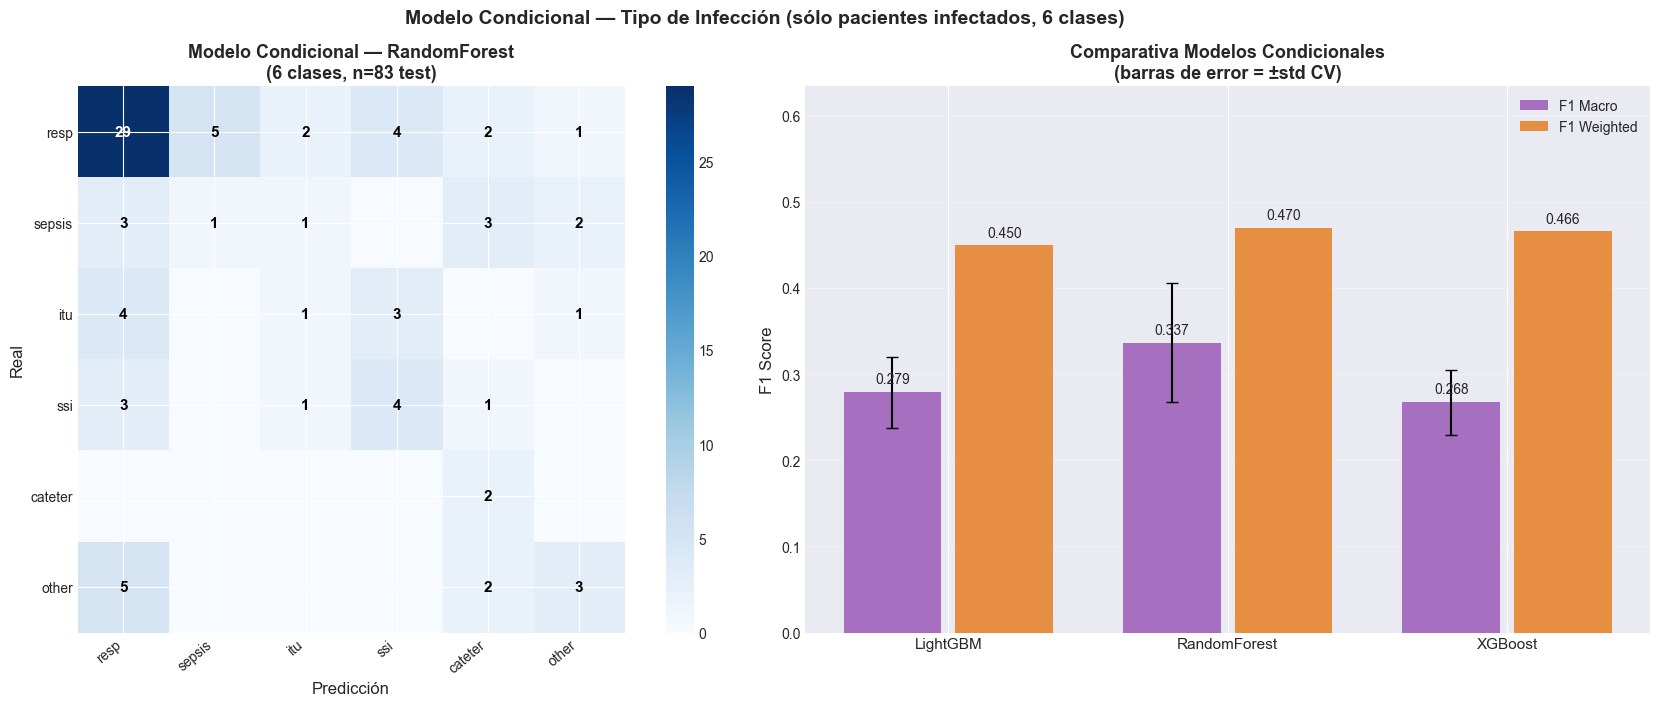

In [99]:
# ─── Visualización: classification report + confusion matrix ─────────────────
print(f'CLASSIFICATION REPORT — {best_cond_nombre} (6 clases, solo infectados)\n')
print(best_cond['classification_report'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusión del mejor modelo condicional
cm_cond = best_cond['confusion_matrix']
n_cls_cond = len(ORDEN_CLASES_6)
im_c = axes[0].imshow(cm_cond, cmap='Blues')
axes[0].set_xticks(range(n_cls_cond)); axes[0].set_xticklabels(ORDEN_CLASES_6, rotation=40, ha='right')
axes[0].set_yticks(range(n_cls_cond)); axes[0].set_yticklabels(ORDEN_CLASES_6)
axes[0].set_xlabel('Predicción', fontsize=12); axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title(f'Modelo Condicional — {best_cond_nombre}\n(6 clases, n={len(X_te_c)} test)', fontsize=13, fontweight='bold')
plt.colorbar(im_c, ax=axes[0])
for i in range(n_cls_cond):
    for j in range(n_cls_cond):
        val = cm_cond[i, j]
        if val > 0:
            axes[0].text(j, i, str(val), ha='center', va='center', fontsize=11, fontweight='bold',
                         color='white' if val > cm_cond.max() * 0.6 else 'black')

# Barras comparativa modelos condicionales
noms_c = list(cond_results.keys())
f1m_c  = [cond_results[n]['f1_macro']    for n in noms_c]
f1w_c  = [cond_results[n]['f1_weighted'] for n in noms_c]
stds_c = [cond_results[n]['cv_std']      for n in noms_c]
xc = np.arange(len(noms_c))
bars_m = axes[1].bar(xc - 0.2, f1m_c, 0.35, label='F1 Macro',    color='#9b59b6', alpha=0.85, yerr=stds_c, capsize=4)
bars_w = axes[1].bar(xc + 0.2, f1w_c, 0.35, label='F1 Weighted', color='#e67e22', alpha=0.85)
for xi, (vm, vw) in enumerate(zip(f1m_c, f1w_c)):
    axes[1].text(xi - 0.2, vm + 0.01, f'{vm:.3f}', ha='center', fontsize=10)
    axes[1].text(xi + 0.2, vw + 0.01, f'{vw:.3f}', ha='center', fontsize=10)
axes[1].set_xticks(xc); axes[1].set_xticklabels(noms_c, fontsize=11)
axes[1].set_ylim(0, max(max(f1m_c), max(f1w_c)) * 1.35)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Comparativa Modelos Condicionales\n(barras de error = ±std CV)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Modelo Condicional — Tipo de Infección (sólo pacientes infectados, 6 clases)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


Calculando SHAP para modelo multiclase — RandomForest...
  SHAP calculado. Shape: (2733, 42, 7)

TOP 15 VARIABLES — MODELO MULTICLASE (RandomForest)
                Variable  SHAP_Importance
           tumor_maligno         0.033870
                    edad         0.022131
            duracion_min         0.020425
           vital_ta_sist         0.019342
           vital_ta_dias         0.018693
                vital_fc         0.017212
           ASA_Anestesia         0.016278
       anestesia_general         0.014157
                    epoc         0.008674
    dm_sin_dano_organico         0.008635
               enf_renal         0.008344
 enf_cardiaca_congestiva         0.007980
           cirugia_mayor         0.007899
tumor_solido_metastasico         0.007456
     suspension_farmacos         0.006778


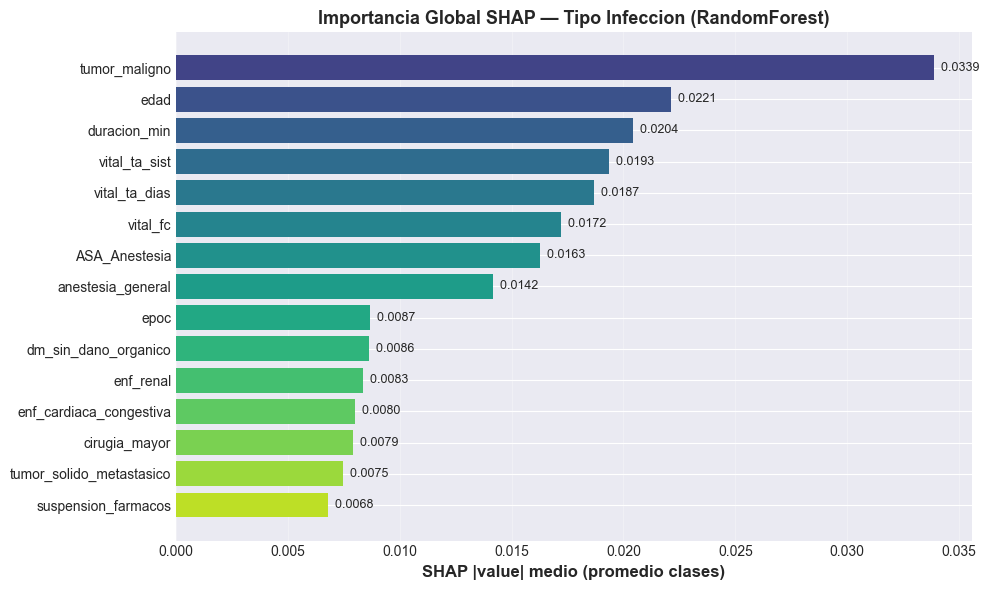

In [100]:
# ─── SHAP para mejor modelo multiclase (7 clases) ────────────────────────────
print(f'Calculando SHAP para modelo multiclase — {best_mc_nombre}...')

best_mc_pipe      = best_mc['best_pipeline']
best_mc_model     = best_mc_pipe.named_steps['model']
preprocessor_mc   = best_mc_pipe.named_steps['preprocessor']
_, cols_mc        = construir_preprocessor(X_train_mc.columns.tolist())
X_test_mc_proc    = pd.DataFrame(preprocessor_mc.transform(X_test_mc), columns=cols_mc)
X_train_mc_proc   = pd.DataFrame(preprocessor_mc.transform(X_train_mc), columns=cols_mc)

if best_mc_nombre in TREE_MODELS:
    explainer_mc  = shap.TreeExplainer(best_mc_model)
    shap_vals_mc  = explainer_mc.shap_values(X_test_mc_proc)
    # shap_vals_mc puede ser lista (una por clase) o array 3D
    if isinstance(shap_vals_mc, list):
        shap_vals_mc = np.array(shap_vals_mc)   # → (n_classes, n_samples, n_features)
else:
    predict_fn_mc = lambda X: best_mc_model.predict_proba(np.array(X))
    X_bg_mc = shap.sample(X_train_mc_proc, min(100, len(X_train_mc_proc)))
    explainer_mc  = shap.KernelExplainer(predict_fn_mc, X_bg_mc)
    shap_vals_mc  = np.array(explainer_mc.shap_values(
        X_test_mc_proc.iloc[:min(300, len(X_test_mc_proc))]))

print(f'  SHAP calculado. Shape: {np.array(shap_vals_mc).shape}')

# ─── Importancia SHAP global (promedio absoluto sobre todas las clases) ───────
# El TreeExplainer de sklearn RandomForest devuelve (n_samples, n_features, n_classes)
# El KernelExplainer / versiones antiguas devuelven (n_classes, n_samples, n_features)
_sv_arr = np.abs(np.array(shap_vals_mc))
if _sv_arr.ndim == 3:
    _n_test = len(X_test_mc_proc)
    if _sv_arr.shape[0] == _n_test:
        # (n_samples, n_features, n_classes) → avg sobre muestras(0) y clases(2)
        shap_importance_mc = _sv_arr.mean(axis=(0, 2))
    else:
        # (n_classes, n_samples, n_features) → avg sobre clases(0) y muestras(1)
        shap_importance_mc = _sv_arr.mean(axis=(0, 1))
else:
    shap_importance_mc = _sv_arr.mean(axis=0)

df_imp_mc = pd.DataFrame({'Variable': cols_mc, 'SHAP_Importance': shap_importance_mc})
df_imp_mc = df_imp_mc.sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)

print(f'\nTOP 15 VARIABLES — MODELO MULTICLASE ({best_mc_nombre})')
print(df_imp_mc.head(15).to_string(index=False))

# ─── Bar chart SHAP importancia ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))
top_mc = df_imp_mc.head(15)
colors_mc = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_mc)))
bars_mc = plt.barh(range(len(top_mc)), top_mc['SHAP_Importance'].values, color=colors_mc)
plt.yticks(range(len(top_mc)), top_mc['Variable'].values, fontsize=10)
for bar, val in zip(bars_mc, top_mc['SHAP_Importance'].values):
    plt.text(val, bar.get_y() + bar.get_height()/2, f'  {val:.4f}', ha='left', va='center', fontsize=9)
plt.xlabel('SHAP |value| medio (promedio clases)', fontsize=12, fontweight='bold')
plt.title(f'Importancia Global SHAP — Tipo Infeccion ({best_mc_nombre})', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


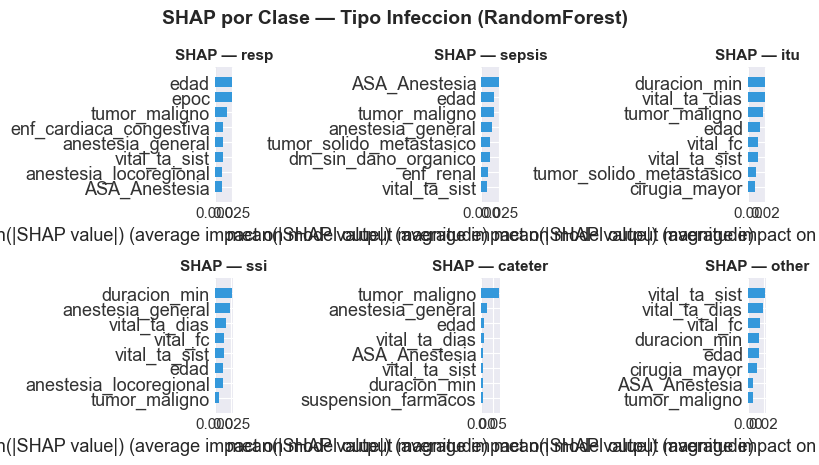

In [102]:
# ─── SHAP summary por clase (clases de infección, excluye 'ninguna') ─────────
_sv_arr2 = np.array(shap_vals_mc)
if _sv_arr2.ndim == 3:
    # Normalizar a (n_classes, n_samples, n_features) para indexar por clase
    if _sv_arr2.shape[0] == len(X_test_mc_proc):
        # (n_samples, n_features, n_classes) → transponer
        _sv_arr2 = _sv_arr2.transpose(2, 0, 1)
    # Ahora shape: (n_classes, n_samples, n_features)
    clases_mostrar = [c for c in ORDEN_CLASES if c != 'ninguna']
    n_cols_plot = min(3, len(clases_mostrar))
    n_rows_plot = (len(clases_mostrar) + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                              figsize=(7 * n_cols_plot, 5 * n_rows_plot))
    axes_flat = np.array(axes).flatten() if hasattr(axes, '__len__') else [axes]
    for idx, clase in enumerate(clases_mostrar):
        clase_idx = ORDEN_CLASES.index(clase)
        sv_clase  = _sv_arr2[clase_idx]          # (n_samples, n_features)
        ax = axes_flat[idx]
        plt.sca(ax)
        shap.summary_plot(sv_clase, X_test_mc_proc, plot_type='bar',
                          max_display=8, show=False, color='#3498db')
        ax.set_title(f'SHAP — {clase}', fontsize=11, fontweight='bold')
    # Ocultar ejes vacíos
    for idx in range(len(clases_mostrar), len(axes_flat)):
        axes_flat[idx].set_visible(False)
    plt.suptitle(f'SHAP por Clase — Tipo Infeccion ({best_mc_nombre})',
                  fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP multiclase no disponible en formato por clase para este modelo.')


In [103]:
# ─── Exportar resultados multiclase ─────────────────────────────────────────
# Tabla comparativa modelos (7 clases)
rows_mc = []
for nombre, res in mc_results.items():
    rows_mc.append({
        'modelo': nombre, 'tipo': '7_clases_global',
        'f1_macro': res['f1_macro'], 'f1_weighted': res['f1_weighted'],
        'accuracy': res['accuracy'], 'cv_f1_macro': res['cv_f1_macro'],
    })
# Tabla modelos condicionales (6 clases)
for nombre, res in cond_results.items():
    rows_mc.append({
        'modelo': nombre, 'tipo': '6_clases_condicional',
        'f1_macro': res['f1_macro'], 'f1_weighted': res['f1_weighted'],
        'accuracy': res['accuracy'], 'cv_f1_macro': res['cv_f1_macro'],
    })

df_mc_export = pd.DataFrame(rows_mc)
df_mc_export.to_csv('results/tabla_modelos_multiclase_infeccion.csv', index=False)
print('✓ Guardado: results/tabla_modelos_multiclase_infeccion.csv')

print('\n' + '=' * 80)
print('RESUMEN FINAL — PREDICCIÓN MULTICLASE TIPO INFECCIÓN')
print('=' * 80)
print(f'\n7 clases (global):')
for nombre, res in sorted(mc_results.items(), key=lambda x: -x[1]['f1_macro']):
    print(f'  {nombre:<16} F1_macro={res["f1_macro"]:.4f} | F1_weighted={res["f1_weighted"]:.4f}')
print(f'\n6 clases (condicional, n=413):')
for nombre, res in sorted(cond_results.items(), key=lambda x: -x[1]['f1_macro']):
    print(f'  {nombre:<16} F1_macro={res["f1_macro"]:.4f} | CV={res["cv_f1_macro"]:.4f}±{res["cv_std"]:.4f}')

print(f'\n✓ Mejor modelo global   : {best_mc_nombre}  (F1 macro={best_mc["f1_macro"]:.4f})')
print(f'✓ Mejor modelo cond.    : {best_cond_nombre}  (F1 macro={best_cond["f1_macro"]:.4f})')


✓ Guardado: results/tabla_modelos_multiclase_infeccion.csv

RESUMEN FINAL — PREDICCIÓN MULTICLASE TIPO INFECCIÓN

7 clases (global):
  RandomForest     F1_macro=0.1951 | F1_weighted=0.9584
  XGBoost          F1_macro=0.1784 | F1_weighted=0.9405
  LightGBM         F1_macro=0.1773 | F1_weighted=0.9108

6 clases (condicional, n=413):
  RandomForest     F1_macro=0.3368 | CV=0.3326±0.0686
  LightGBM         F1_macro=0.2793 | CV=0.2803±0.0412
  XGBoost          F1_macro=0.2676 | CV=0.2460±0.0377

✓ Mejor modelo global   : RandomForest  (F1 macro=0.1951)
✓ Mejor modelo cond.    : RandomForest  (F1 macro=0.3368)
